# Topic and Journal Analysis

This Notebooks centers in the analysis of topics and journals using data of the next list of authors, considered the Target Authors.

* Ciampitti
* Basso
* Kaiyu
* Grassini
* Archontoulis
* Castellano
* Lobell
* Peng
* Vara Prasad
* Rattalino
* Hoogenboom
* Messina

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy import stats
from scipy.stats import gaussian_kde
ACTUAL_Y= pd.Timestamp.now().year
TOPIC_COL = "primary_topic"
TOPIC_LEVEL_LABEL = TOPIC_COL.replace("topic_", "").replace("_", " ").capitalize()
# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

In [35]:
def filter_categories_by_mean_plus_one(
    df,
    group_cols,
    paper_id_col="article_id",
    label=None,
    print_summary=True,
):
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    required_cols = list(group_cols)
    if paper_id_col in df.columns:
        required_cols.append(paper_id_col)

    base = df.dropna(subset=required_cols).copy()
    if base.empty:
        empty_idx = pd.Index([], dtype="object") if len(group_cols) == 1 else pd.MultiIndex.from_tuples([], names=group_cols)
        return base, pd.Series(dtype=float), empty_idx, 1, 0.0

    if paper_id_col in base.columns:
        counts = base.groupby(group_cols)[paper_id_col].nunique().sort_values(ascending=False)
    else:
        counts = base.groupby(group_cols).size().sort_values(ascending=False)

    mean_papers = float(counts.mean()) if len(counts) > 0 else 0.0
    min_papers = int(np.floor(mean_papers)) + 1
    eligible = counts[counts >= min_papers]

    if len(group_cols) == 1:
        key = group_cols[0]
        filtered = base[base[key].isin(eligible.index)].copy()
    else:
        eligible_df = eligible.rename("n_papers").reset_index()[group_cols]
        filtered = base.merge(eligible_df, on=group_cols, how="inner")

    if print_summary:
        tag = label or ", ".join(group_cols)
        print(
            f"[{tag}] mean papers={mean_papers:.2f}, threshold={min_papers}, "
            f"kept categories={len(eligible)}/{len(counts)}"
        )

    return filtered, counts, eligible.index, min_papers, mean_papers

def annotate_points(ax, x_values, y_values, color):
        for x_value, y_value in zip(x_values, y_values):
            if pd.notna(y_value):
                ax.annotate(
                    f"{y_value:.0f}",
                    (x_value, y_value),
                    textcoords="offset points",
                    xytext=(0, 6),
                    ha="center",
                    fontsize=8,
                    color=color,
                )

def compute_impact_factor(
    df: pd.DataFrame,
    group_col: str,
    reference_years: list[int] | None = None,
    min_papers: int = 2,
) -> pd.DataFrame:
    """
    Compute Classic 2-Year Impact Factor per entity (journal or topic)
    for each reference year.
 
    Parameters
    ----------
    df : DataFrame with columns: publication_year, citations_year_1,
         citations_year_2, and `group_col`.
    group_col : column to group by, e.g. 'journal_display_name' or 'primary_topic'.
    reference_years : list of years to compute IF for.
                      Defaults to all feasible years in the data.
    min_papers : minimum number of papers (Y-1 + Y-2) required to report an IF.
                 Entities with fewer papers get NaN to avoid noisy estimates.
 
    Returns
    -------
    DataFrame with columns: group_col, reference_year, n_papers_y1, n_papers_y2,
    n_papers_total, citations_from_y1, citations_from_y2, impact_factor.
    """
    pub_years = sorted(df["publication_year"].unique())
    min_pub, max_pub = min(pub_years), max(pub_years)
 
    if reference_years is None:
        # Need pub_year Y-2 and Y-1 to exist in data, and year_1/year_2 columns
        # to be populated. Feasible reference years start at min_pub+2.
        reference_years = list(range(min_pub + 2, max_pub + 2))
 
    records = []
 
    for Y in reference_years:
        # Papers published in Y-1 (contribute citations_year_1)
        papers_y1 = df[df["publication_year"] == Y - 1][[group_col, "citations_year_1"]].copy()
        papers_y1.columns = [group_col, "cite_contrib"]
 
        # Papers published in Y-2 (contribute citations_year_2)
        papers_y2 = df[df["publication_year"] == Y - 2][[group_col, "citations_year_2"]].copy()
        papers_y2.columns = [group_col, "cite_contrib"]
 
        # Aggregate per entity
        for entity, grp_y1 in papers_y1.groupby(group_col):
            grp_y2 = papers_y2[papers_y2[group_col] == entity]
 
            n_y1 = len(grp_y1)
            n_y2 = len(grp_y2)
            n_total = n_y1 + n_y2
 
            cites_y1 = grp_y1["cite_contrib"].sum(min_count=1)   # NaN if all missing
            cites_y2 = grp_y2["cite_contrib"].sum(min_count=1) if n_y2 > 0 else 0.0
 
            # Both years need at least some data
            total_cites = (
                (cites_y1 if pd.notna(cites_y1) else 0.0) +
                (cites_y2 if pd.notna(cites_y2) else 0.0)
            )
 
            if n_total >= min_papers:
                if_ = total_cites / n_total
            else:
                if_ = np.nan  # too few papers — unreliable
 
            records.append({
                group_col: entity,
                "reference_year": Y,
                "n_papers_y1": n_y1,
                "n_papers_y2": n_y2,
                "n_papers_total": n_total,
                "citations_from_y1": cites_y1,
                "citations_from_y2": cites_y2,
                "impact_factor": round(if_, 3) if pd.notna(if_) else np.nan,
            })
 
    result = pd.DataFrame(records)
    return result.sort_values([group_col, "reference_year"]).reset_index(drop=True)

def calculate_group_metrics(df, group_col, citations_col='cited_by_count'):
    """
    Calculate H-index, i10-index, mean and median citations for each group (journal or topic).
    
    Parameters:
    - df: pandas DataFrame with group (journal/topic) and citation info
    - group_col: column name to group by (e.g., 'journal_name' or 'primary_topic')
    - citations_col: column name for citation counts
    
    Returns:
    - metrics_df: DataFrame with one row per group and columns:
        ['h_index', 'i10_index', 'mean_citations', 'median_citations']
    """
    metrics_list = []

    for group, group_df in df.groupby(group_col):
        citations = sorted(group_df[citations_col], reverse=True)
        
        # H-index
        h_index = 0
        for i, c in enumerate(citations, start=1):
            if c >= i:
                h_index = i
            else:
                break
        
        # i10-index
        i10_index = sum(c >= 10 for c in citations)
        
        metrics_list.append({
            group_col: group,
            'h_index': h_index,
            'i10_index': i10_index,
            'mean_citations': group_df[citations_col].mean(),
            'median_citations': group_df[citations_col].median()
        })
    
    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df

In [36]:
filtered_TargetA_df_corr=pd.read_csv("/home/ramir713/PublicationAnalysis/data/filtered_TargetA_df_corr.csv")
filtered_all_df = pd.read_csv("/home/ramir713/PublicationAnalysis/data/filtered_all_df.csv")
filtered_all_df_corr = pd.read_csv("/home/ramir713/PublicationAnalysis/data/filtered_all_df_corr.csv")
filtered_TargetA_df_corr.columns
JOURNAL_IF_2025=pd.read_csv("/home/ramir713/PublicationAnalysis/data/JOURNAL_IF_2025.csv")

In [37]:
# ---- One-time citation preprocessing ----


filtered_TargetA_df_corr["publication_year"] = pd.to_numeric(
    filtered_TargetA_df_corr["publication_year"], errors="coerce"
)

citation_year_cols = sorted(
    [col for col in filtered_TargetA_df_corr.columns if col.startswith("citations_year_")],
    key=lambda col: int(col.rsplit("_", 1)[-1]),
)



filtered_TargetA_df_corr[citation_year_cols] = filtered_TargetA_df_corr[citation_year_cols].apply(
    pd.to_numeric, errors="coerce"
)

targetA_citations_long = (
    filtered_TargetA_df_corr[["article_id", "publication_year", TOPIC_COL] + citation_year_cols]
    .melt(
        id_vars=["article_id", "publication_year", TOPIC_COL],
        value_vars=citation_year_cols,
        var_name="cit_col",
        value_name="citations",
    )
)

offset_series = pd.to_numeric(
    targetA_citations_long["cit_col"].str.extract(r"(\d+)$", expand=False),
    errors="coerce",
)
valid_offsets = offset_series.notna()
targetA_citations_long = targetA_citations_long.loc[valid_offsets].copy()
targetA_citations_long["offset"] = offset_series.loc[valid_offsets].astype(int)
targetA_citations_long["calendar_year"] = (
    targetA_citations_long["publication_year"].astype("Int64") + targetA_citations_long["offset"]
)
targetA_citations_long["citation_age"] = targetA_citations_long["offset"]
targetA_citations_long["citations"] = targetA_citations_long["citations"].fillna(0)

targetA_citations_first2 = targetA_citations_long[
    targetA_citations_long["citation_age"].between(0, 1)
].copy()

print(
    "Prepared targetA_citations_first2:",
    f"wide_rows={len(filtered_TargetA_df_corr)}",
    f"long_rows={len(targetA_citations_long)}",
    f"first2_rows={len(targetA_citations_first2)}",
    f"calendar_year_range={int(targetA_citations_first2['calendar_year'].min())}"
    f"-{int(targetA_citations_first2['calendar_year'].max())}",
)


Prepared targetA_citations_first2: wide_rows=391 long_rows=3519 first2_rows=782 calendar_year_range=2018-2026


# Topic section

[topics:Primary topic] mean papers=5.51, threshold=6, kept categories=16/69


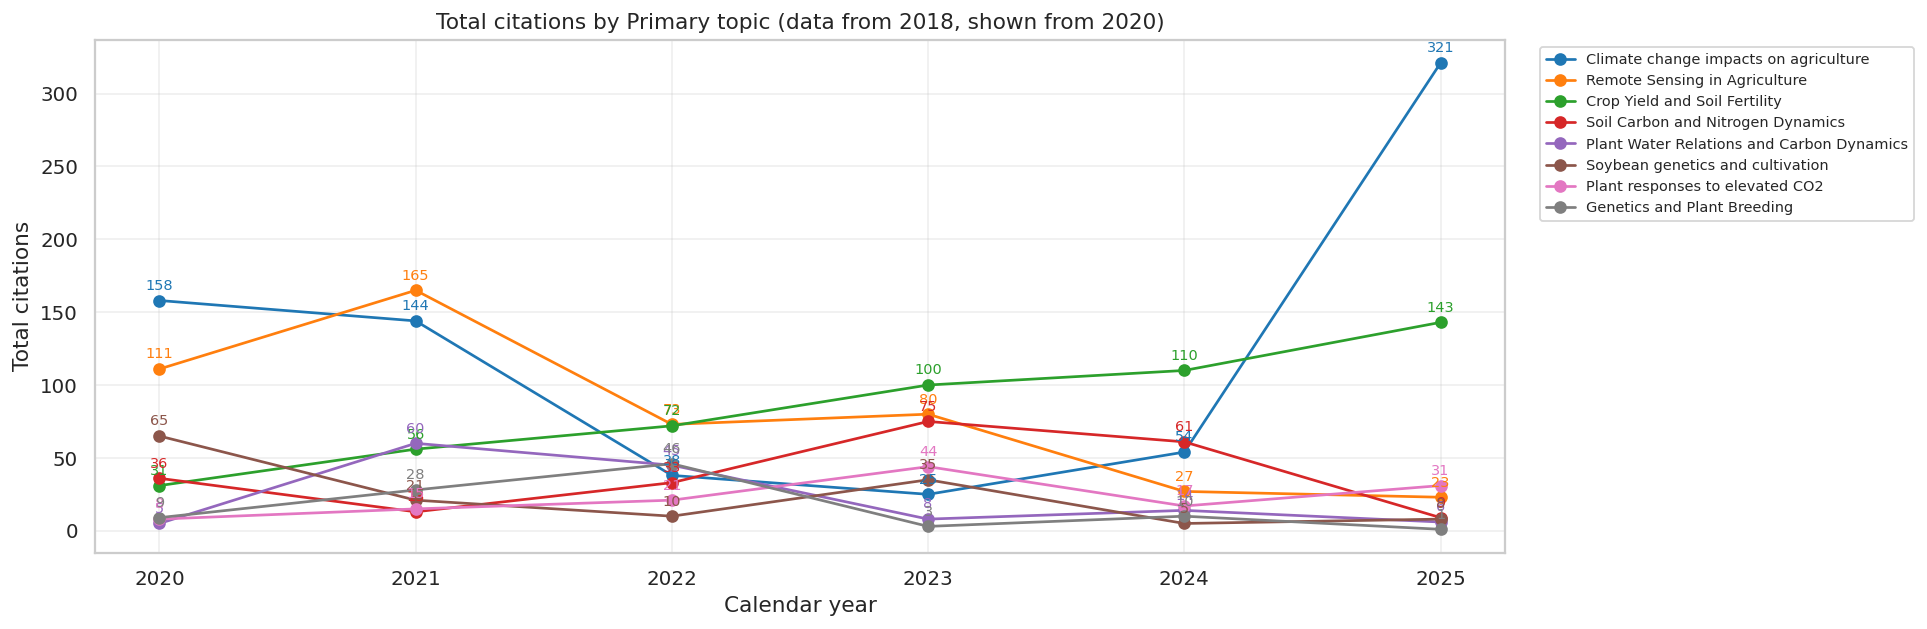

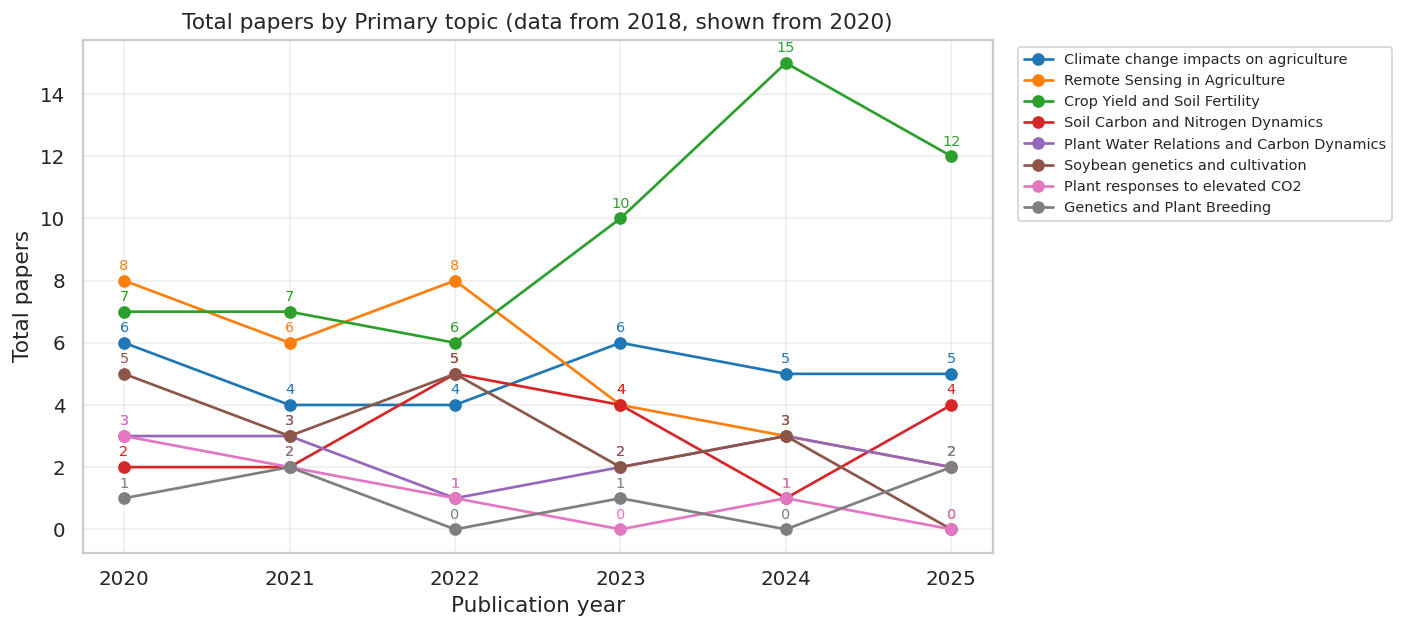

In [38]:
# ---- Target authors (corresponding): topic citation analysis ----
topic_col = TOPIC_COL
data_start_year = 2018
plot_start_year = 2020
end_year = 2025

df_topic = (
    targetA_citations_first2
    .dropna(subset=[topic_col, "publication_year", "calendar_year"])
    .copy()
)

df_topic["publication_year"] = df_topic["publication_year"].astype(int)
df_topic["calendar_year"] = df_topic["calendar_year"].astype(int)

# Category eligibility (across all years combined): papers >= floor(mean) + 1
df_topic, topic_paper_counts, eligible_topics_idx, topic_min_papers, _ = filter_categories_by_mean_plus_one(
    df_topic,
    topic_col,
    paper_id_col="article_id",
    label=f"topics:{TOPIC_LEVEL_LABEL}",
)

if df_topic.empty:
    print(f"No topic data available after threshold filtering (>= {topic_min_papers} papers).")
    topic_year_stats = pd.DataFrame()
    top_topics = []
    topic_year_top = pd.DataFrame()
    topic_color = {}
else:
    df_topic = df_topic[df_topic["calendar_year"].between(data_start_year, end_year)].copy()

    topic_year_stats = (
        df_topic.groupby(["calendar_year", topic_col])
        .agg(
            total_citations=("citations", "sum"),
            n_papers=("article_id", "nunique"),
        )
        .reset_index()
    )

    topic_year_stats["avg_citations_per_paper"] = (
        topic_year_stats["total_citations"] / topic_year_stats["n_papers"].where(topic_year_stats["n_papers"] > 0)
    )

    top_topics = (
        topic_year_stats.groupby(topic_col)["total_citations"]
        .sum()
        .nlargest(8)
        .index.tolist()
    )

    topic_year_top = topic_year_stats[topic_year_stats[topic_col].isin(top_topics)]
    colors = sns.color_palette("tab10", n_colors=len(top_topics))
    topic_color = dict(zip(top_topics, colors))

    # ---- Total citations per year (top topics) ----
    pivot_total = (
        topic_year_top.pivot_table(
            index="calendar_year", columns=topic_col, values="total_citations", fill_value=0
        )
    )
    pivot_total = pivot_total.reindex(columns=top_topics, fill_value=0)
    pivot_total = pivot_total.loc[pivot_total.index >= plot_start_year]

    fig, ax = plt.subplots(figsize=(15, 5))
    for topic in top_topics:
        ax.plot(pivot_total.index, pivot_total[topic], marker="o", label=topic, color=topic_color[topic])
        annotate_points(ax, pivot_total.index, pivot_total[topic], topic_color[topic])
    ax.set_title(f"Total citations by {TOPIC_LEVEL_LABEL} (data from 2018, shown from 2020)")
    ax.set_xlabel("Calendar year")
    ax.set_ylabel("Total citations")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    # ---- Total papers per year (top topics, publication year only) ----
    paper_year_stats = (
        df_topic[df_topic[topic_col].isin(top_topics) & df_topic["publication_year"].between(data_start_year, end_year)]
        .groupby(["publication_year", topic_col])
        .agg(n_papers=("article_id", "nunique"))
        .reset_index()
    )
    pivot_papers = paper_year_stats.pivot_table(
        index="publication_year", columns=topic_col, values="n_papers", fill_value=0
    )
    pivot_papers = pivot_papers.reindex(columns=top_topics, fill_value=0)
    pivot_papers = pivot_papers.loc[pivot_papers.index >= plot_start_year]

    fig, ax = plt.subplots(figsize=(11, 5))
    for topic in top_topics:
        ax.plot(
            pivot_papers.index,
            pivot_papers[topic],
            marker="o",
            label=topic,
            color=topic_color[topic],
        )
        annotate_points(ax, pivot_papers.index, pivot_papers[topic], topic_color[topic])
    ax.set_title(f"Total papers by {TOPIC_LEVEL_LABEL} (data from 2018, shown from 2020)")
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Total papers")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


Plotting avg citations per paper for topics with more than 4.59 papers:


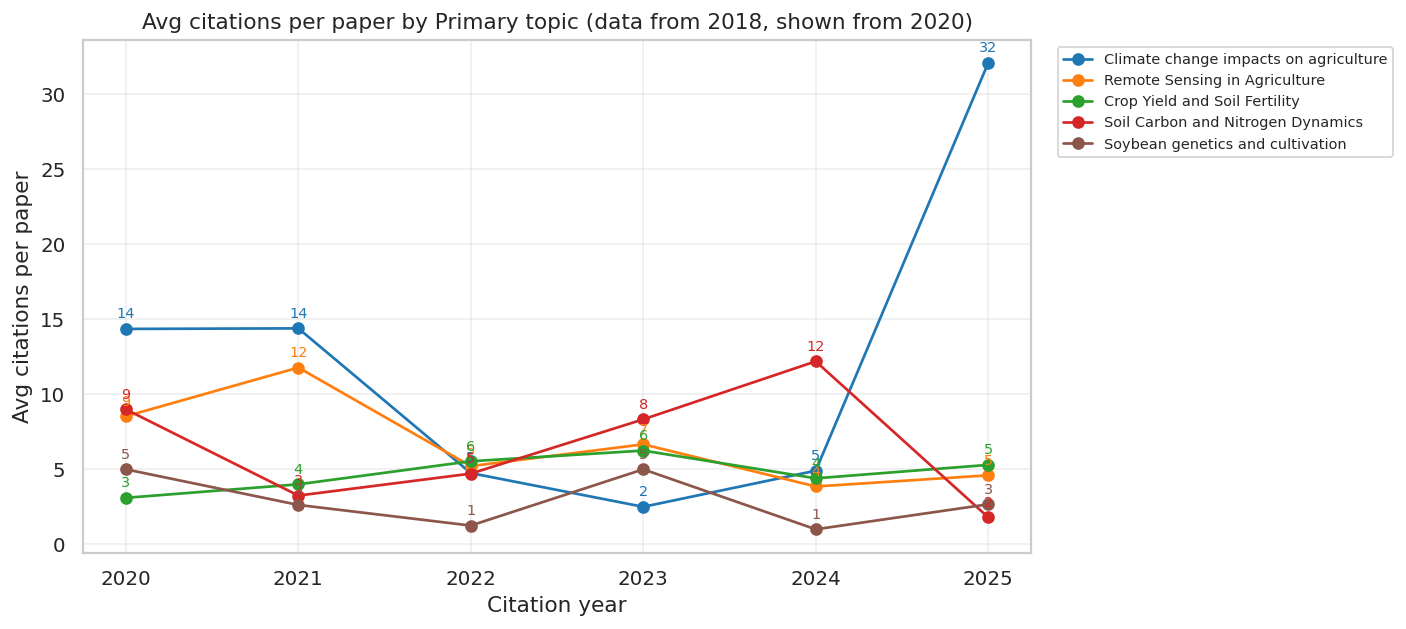

In [39]:
# ---- Avg citations per paper per year (top topics, filtered by mean papers) ----
# Calculate mean number of papers per topic (across all years)
topic_mean_papers = topic_year_stats.groupby(topic_col)["n_papers"].mean()
mean_papers = topic_mean_papers.mean()

# Only keep topics with >= mean number of papers
topics_above_mean = topic_mean_papers[topic_mean_papers >= mean_papers].index.tolist()
top_topics_avg = [t for t in top_topics if t in topics_above_mean ]

if topic_year_top.empty or not top_topics_avg:
    print("No eligible topic averages to plot after mean-paper filtering.")
else:
    print(f"Plotting avg citations per paper for topics with more than {mean_papers:.2f} papers:")
    fig, ax = plt.subplots(figsize=(11, 5))
    for topic in top_topics_avg:
        grp = topic_year_top[
            (topic_year_top[topic_col] == topic)
            & (topic_year_top["calendar_year"] >= plot_start_year)
        ].sort_values("calendar_year")
        ax.plot(
            grp["calendar_year"],
            grp["avg_citations_per_paper"],
            marker="o",
            label=topic,
            color=topic_color[topic],
        )
        annotate_points(ax, grp["calendar_year"], grp["avg_citations_per_paper"], topic_color[topic])
    ax.set_title(f"Avg citations per paper by {TOPIC_LEVEL_LABEL} (data from 2018, shown from 2020)")
    ax.set_xlabel("Citation year")
    ax.set_ylabel("Avg citations per paper")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
    

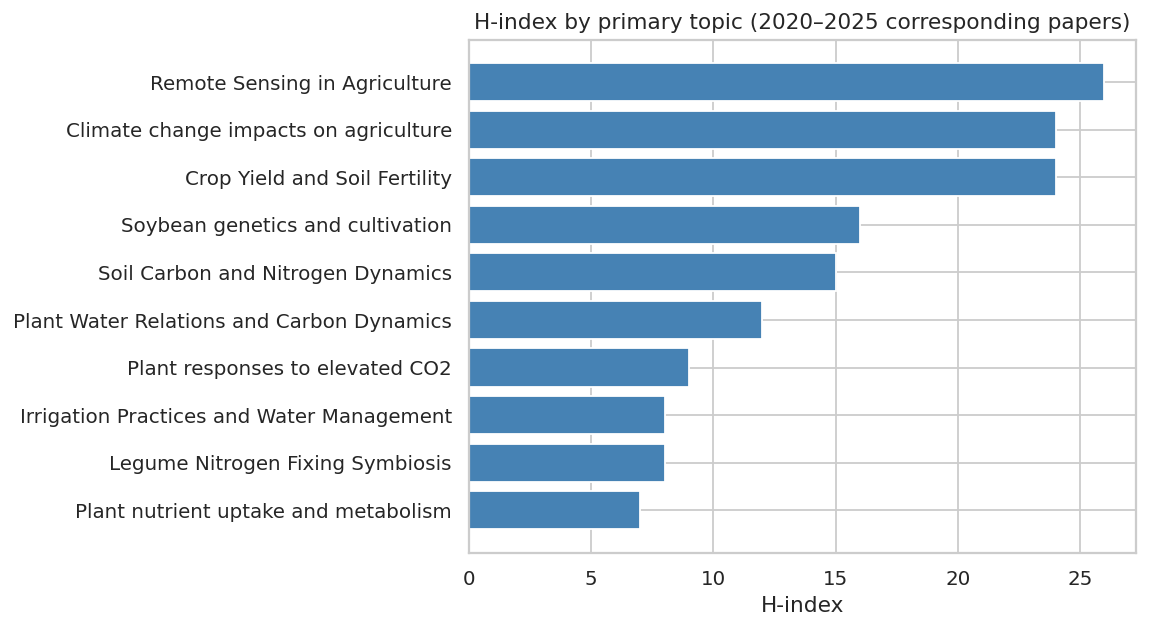

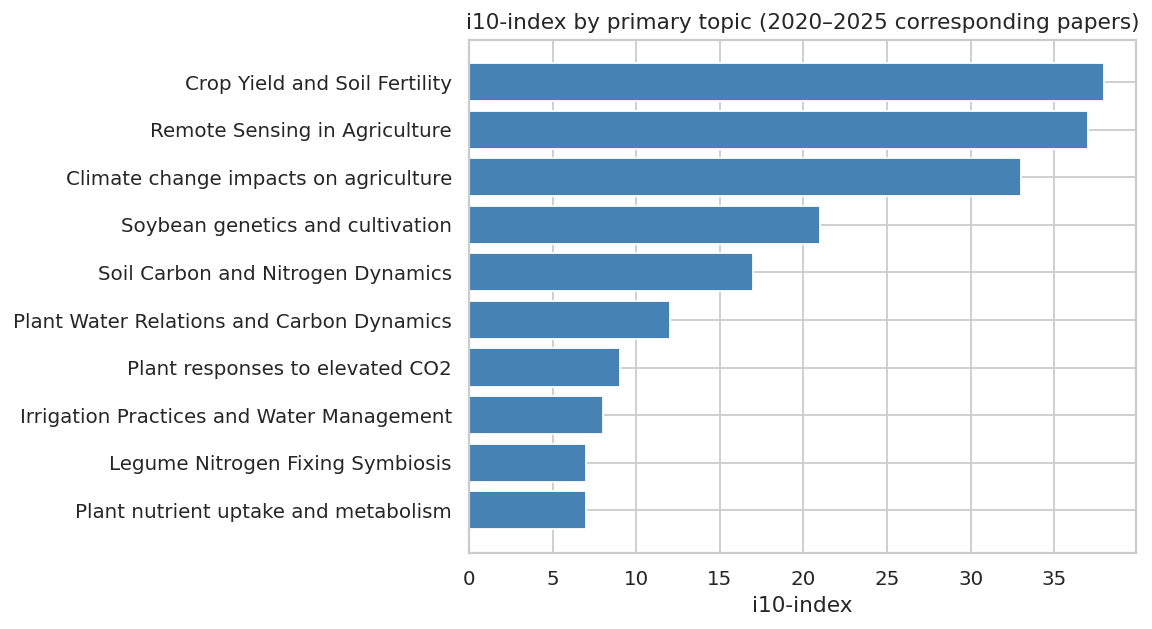

In [40]:

topic_metrics = calculate_group_metrics(filtered_TargetA_df_corr, group_col='primary_topic', citations_col='total_citations')

topic_metrics_h = (
    topic_metrics.dropna(subset=["h_index"])
    .sort_values("h_index", ascending=True)
    .tail(10)
)
plt.figure(figsize=(9, 5))
plt.barh(topic_metrics_h["primary_topic"], topic_metrics_h["h_index"], color="steelblue")
plt.xlabel("H-index")
plt.title("H-index by primary topic (2020–2025 corresponding papers)")
plt.tight_layout()
plt.show()

topic_metrics_i10 = (
    topic_metrics.dropna(subset=["i10_index"])
    .sort_values("i10_index", ascending=True)
    .tail(10)
)
plt.figure(figsize=(9, 5))
plt.barh(topic_metrics_i10["primary_topic"], topic_metrics_i10["i10_index"], color="steelblue")
plt.xlabel("i10-index")
plt.title("i10-index by primary topic (2020–2025 corresponding papers)")
plt.tight_layout()
plt.show()

In [41]:
# Top 3 topics by total citations, then top 3 authors by average citations within each topic

paper_topic_author = (
    filtered_TargetA_df_corr[[TOPIC_COL, "queried_author", "article_id", "total_citations"]]
    .dropna(subset=[TOPIC_COL, "queried_author", "article_id", "total_citations"])
    .copy()
)

# Aggregate topics by total citations across all corresponding papers
top_topics_summary = (
    paper_topic_author.groupby(TOPIC_COL, as_index=False)
    .agg(
        total_citations=("total_citations", "sum"),
        n_papers=("article_id", "nunique"),
    )
    .sort_values(["total_citations", "n_papers"], ascending=[False, False])
    .head(3)
    .reset_index(drop=True)
)

top_topics = top_topics_summary[TOPIC_COL].tolist()

# For each of the top topics, rank authors by average citations per paper within that topic
# Only authors with at least 3 papers can enter the top list.
top_authors_by_topic = (
    paper_topic_author[paper_topic_author[TOPIC_COL].isin(top_topics)]
    .groupby([TOPIC_COL, "queried_author"], as_index=False)
    .agg(
        avg_citations_per_paper=("total_citations", "mean"),
        total_citations=("total_citations", "sum"),
        n_papers=("article_id", "nunique"),
    )
    .query("n_papers >= 3")
    .sort_values([TOPIC_COL, "avg_citations_per_paper", "n_papers"], ascending=[True, False, False])
    .groupby(TOPIC_COL, group_keys=False)
    .head(3)
    .reset_index(drop=True)
)


In [42]:
print("Top 3 topics by total citations (all years, corresponding papers)")
display(top_topics_summary)

print("Top 3 authors by average citations within each top topic")
display(top_authors_by_topic)


Top 3 topics by total citations (all years, corresponding papers)


,primary_topic,total_citations,n_papers
0,Remote Sensing in Agriculture,3543,42
1,Climate change impacts on agriculture,3412,41
2,Crop Yield and Soil Fertility,1671,65


Top 3 authors by average citations within each top topic


,primary_topic,queried_author,avg_citations_per_paper,total_citations,n_papers
0,Climate change impacts on agriculture,Kaiyu,237.000000,948,4
1,Climate change impacts on agriculture,Lobell,181.600000,908,5
2,Climate change impacts on agriculture,Peng,144.666667,434,3
3,Crop Yield and Soil Fertility,Grassini,75.333333,226,3
4,Crop Yield and Soil Fertility,Messina,51.666667,155,3
5,Crop Yield and Soil Fertility,Ciampitti,27.545455,909,33
6,Remote Sensing in Agriculture,Kaiyu,102.956522,2368,23
7,Remote Sensing in Agriculture,Ciampitti,68.000000,680,10
8,Remote Sensing in Agriculture,Basso,48.600000,243,5


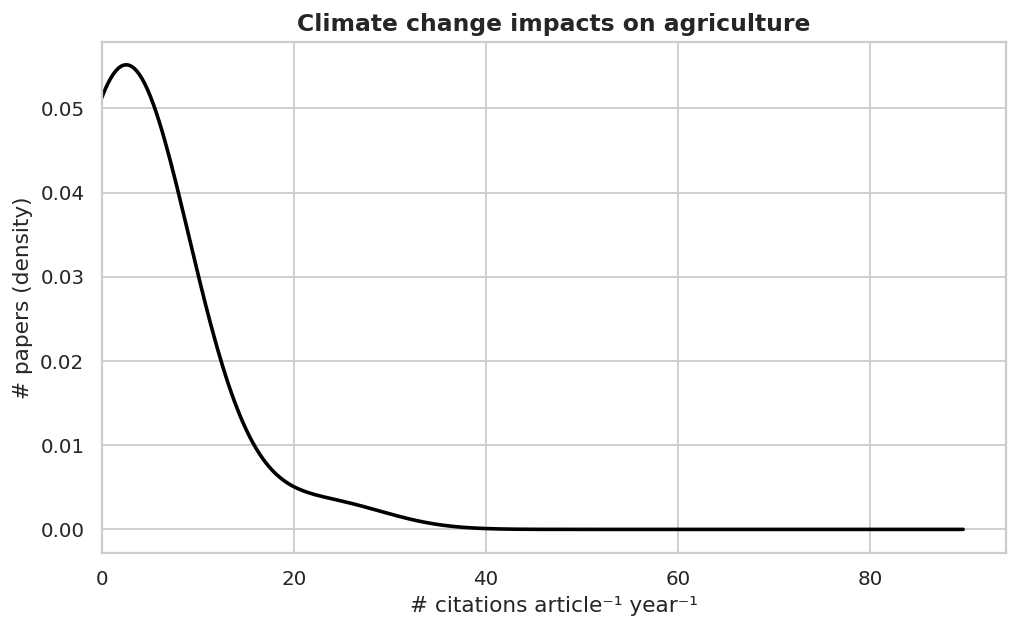

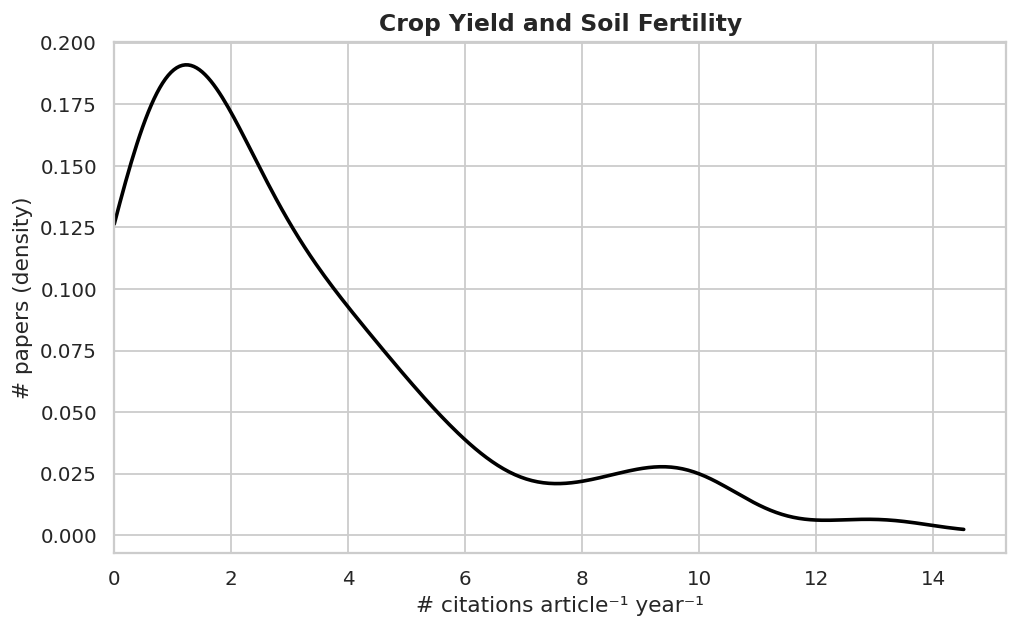

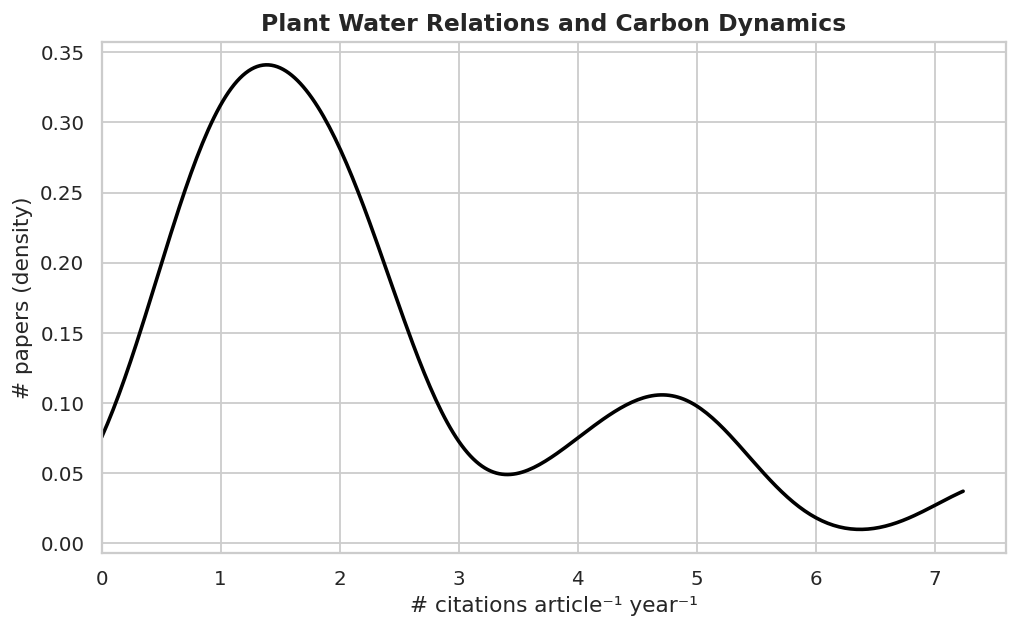

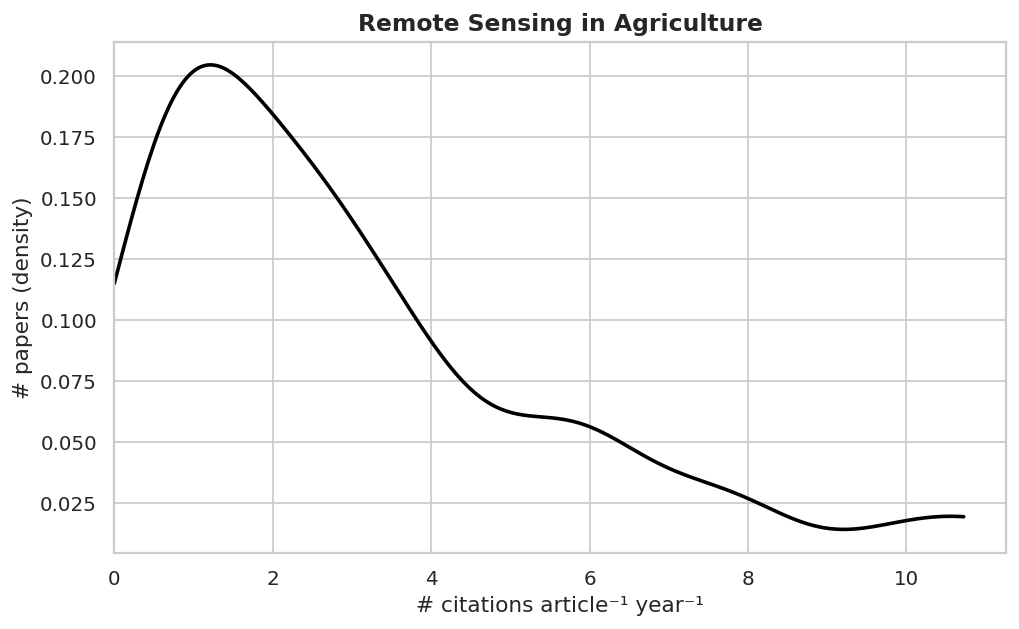

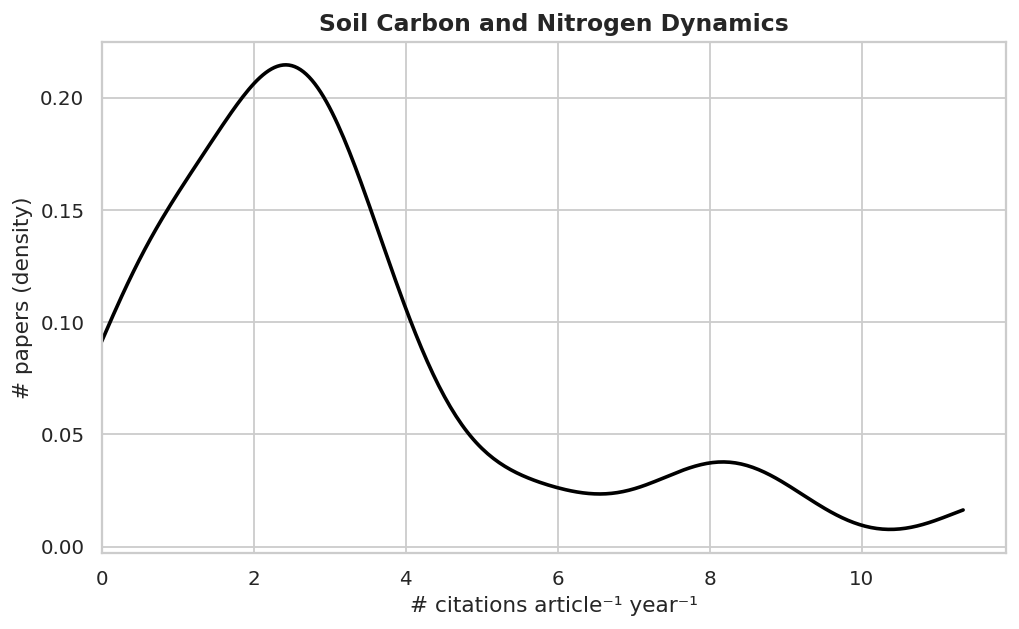

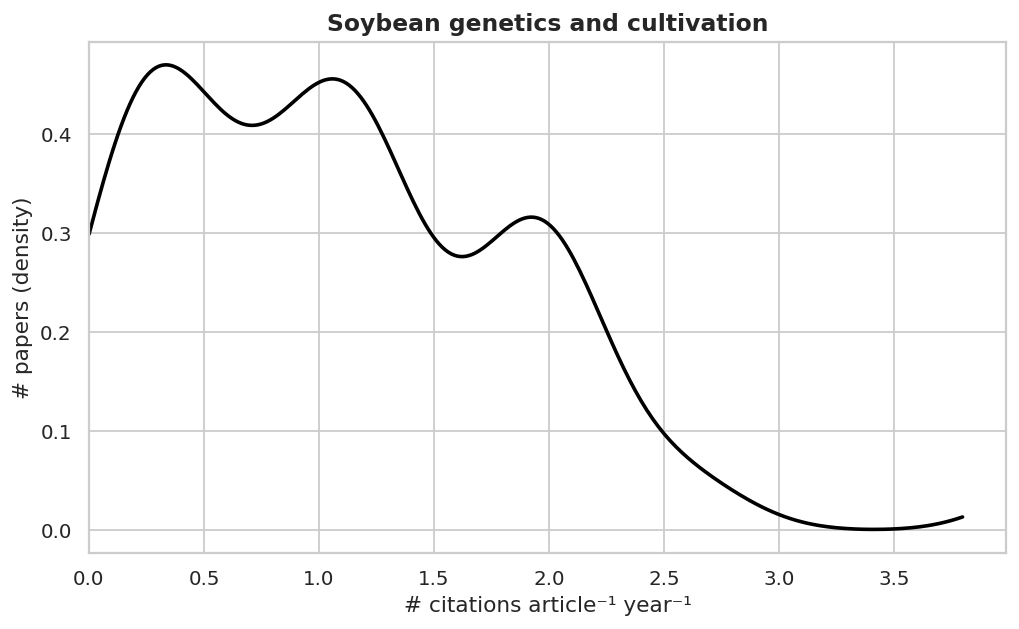

In [43]:
df = (targetA_citations_first2
      .groupby("article_id", as_index=False)
      .agg({
          "citations": "sum",
          "publication_year": "first",
          "primary_topic": "first",
          
      })
      .rename(columns={"citations": "total_citations"})
)

df["citations_per_year"] = (
    df["total_citations"] /
    (ACTUAL_Y - df["publication_year"])
)
for group_name, group_df in df.groupby('primary_topic'):
    data = group_df['citations_per_year'].dropna()
    data = data[data > 0]

    if len(data) < 15:
            continue

    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(0, data.quantile(0.99), 300)
    y = kde(x)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y, color="black", linewidth=2)
    ax.set_xlabel("# citations article⁻¹ year⁻¹", fontsize=12)
    ax.set_ylabel("# papers (density)", fontsize=12)
    ax.set_title(group_name, fontsize=13, fontweight="bold")
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()

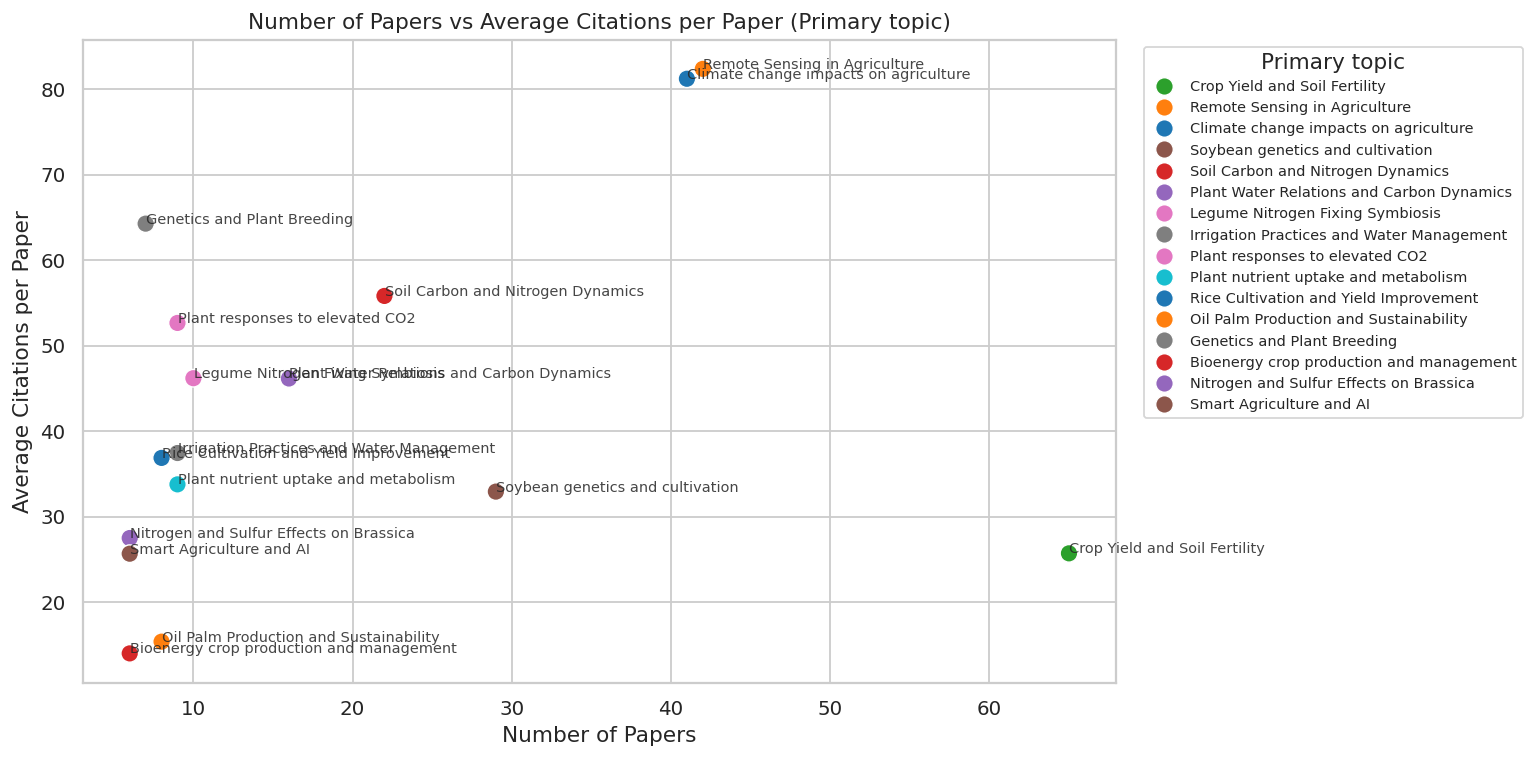

Mean papers across all topics: 5.51


,primary_topic,n_papers,avg_citations_per_paper
14,Crop Yield and Soil Fertility,65,25.707692
52,Remote Sensing in Agriculture,42,82.395349
13,Climate change impacts on agriculture,41,81.238095
63,Soybean genetics and cultivation,29,32.931034
58,Soil Carbon and Nitrogen Dynamics,22,55.826087
45,Plant Water Relations and Carbon Dynamics,16,46.166667
31,Legume Nitrogen Fixing Symbiosis,10,46.200000
28,Irrigation Practices and Water Management,9,37.444444
47,Plant responses to elevated CO2,9,52.666667
46,Plant nutrient uptake and metabolism,9,33.777778


In [44]:
topic_summary = (
    filtered_TargetA_df_corr[[TOPIC_COL, "article_id", "total_citations"]]
    .dropna(subset=[TOPIC_COL, "article_id", "total_citations"])
    .groupby(TOPIC_COL, as_index=False)
    .agg(
        n_papers=("article_id", "nunique"),
        avg_citations_per_paper=("total_citations", "mean"),
    )
)

mean_papers_topics = topic_summary["n_papers"].mean()
topic_summary = (
    topic_summary[topic_summary["n_papers"] >= mean_papers_topics]
    .sort_values("n_papers", ascending=False)
)

topics_order = topic_summary[TOPIC_COL].tolist()
base_palette = sns.color_palette("tab10", n_colors=max(len(topics_order), 10))

topic_palette = {
        topic: topic_color.get(topic, base_palette[i % len(base_palette)])
        for i, topic in enumerate(topics_order)
    }


plt.figure(figsize=(12, 6))
ax = sns.scatterplot(
    data=topic_summary,
    x="n_papers",
    y="avg_citations_per_paper",
    hue=TOPIC_COL,
    palette=topic_palette,
    s=95,
)

for _, row in topic_summary.iterrows():
    plt.text(
        row["n_papers"] + 0.03,
        row["avg_citations_per_paper"] + 0.03,
        str(row[TOPIC_COL]),
        fontsize=8,
        alpha=0.85,
    )

plt.title(f"Number of Papers vs Average Citations per Paper ({TOPIC_LEVEL_LABEL})")
plt.xlabel("Number of Papers")
plt.ylabel("Average Citations per Paper")
ax.legend(title=TOPIC_LEVEL_LABEL, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Mean papers across all topics: {mean_papers_topics:.2f}")
topic_summary

Topics considered: 69
Mean papers across topics: 5.51
Filter threshold: mean + 5 = 10.51
Topics selected: 6


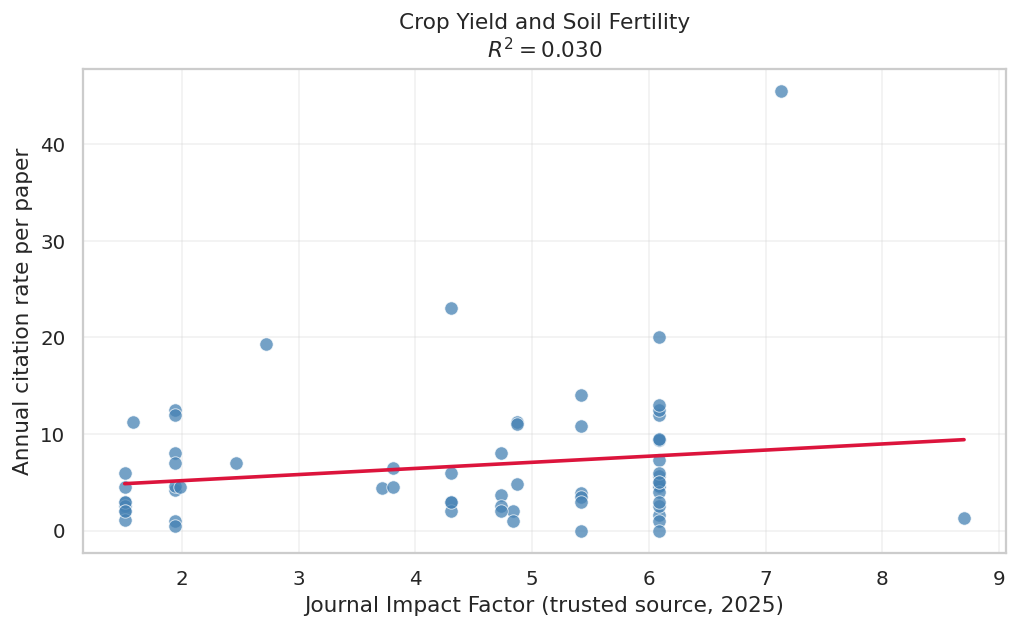

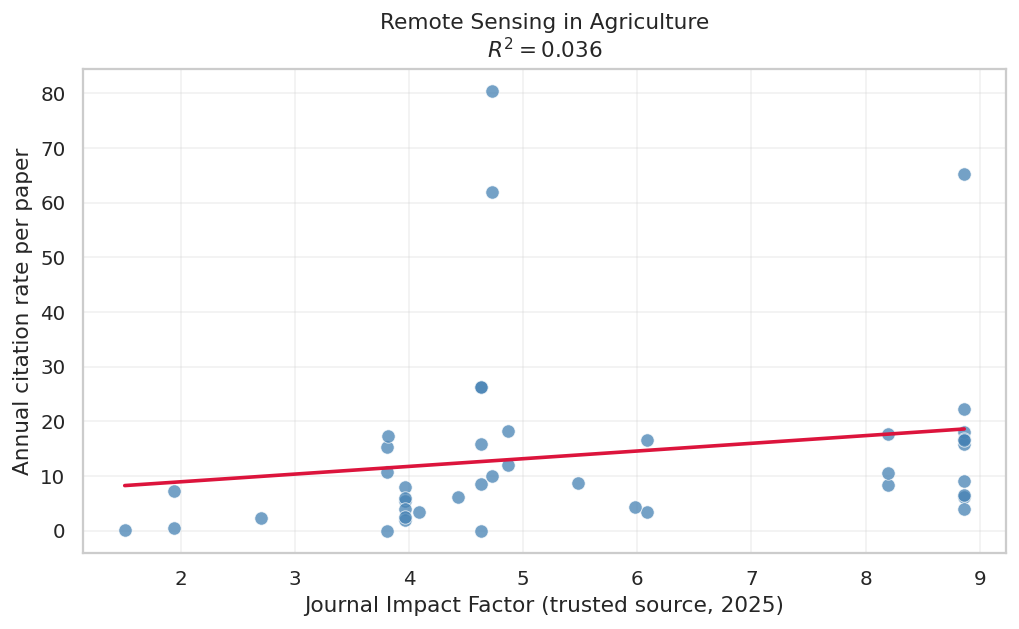

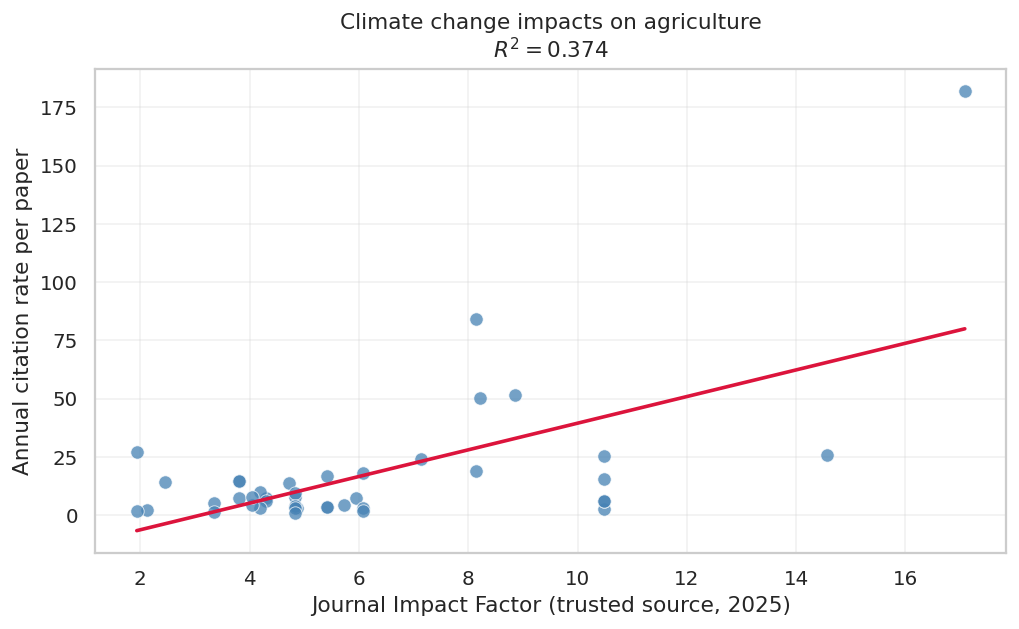

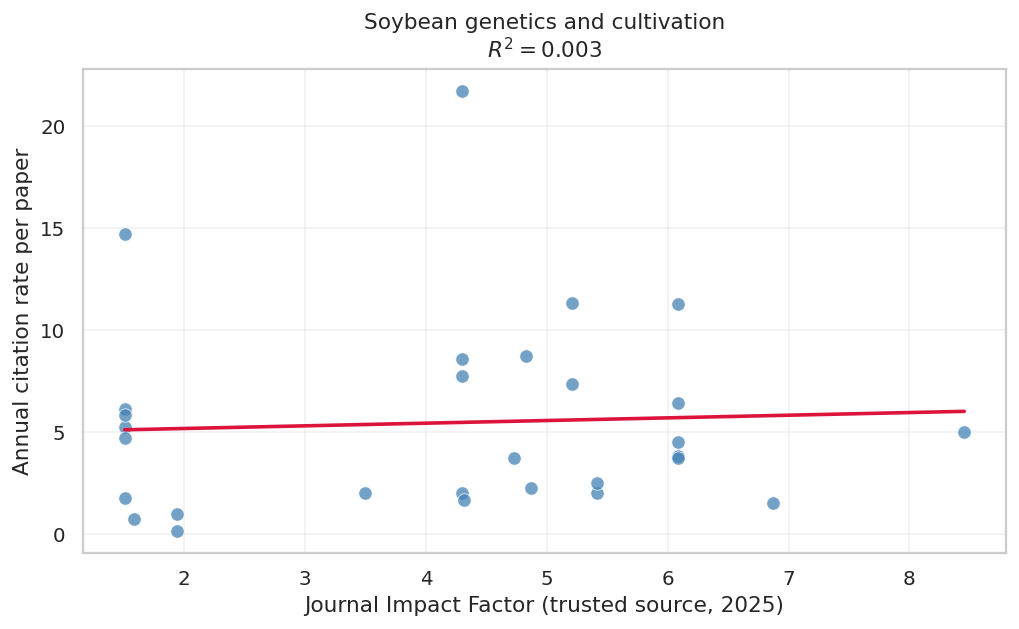

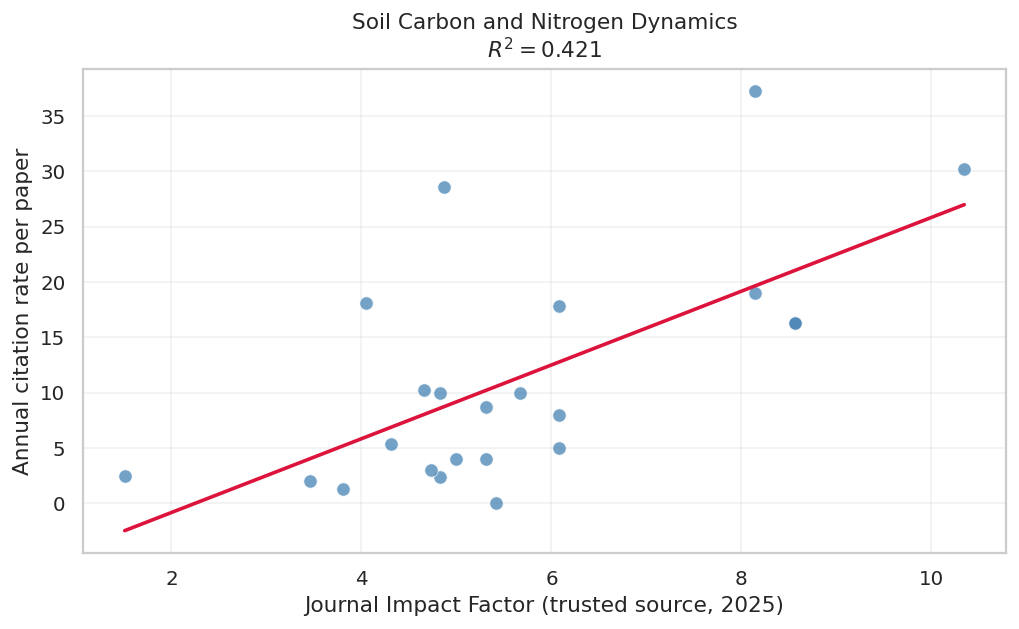

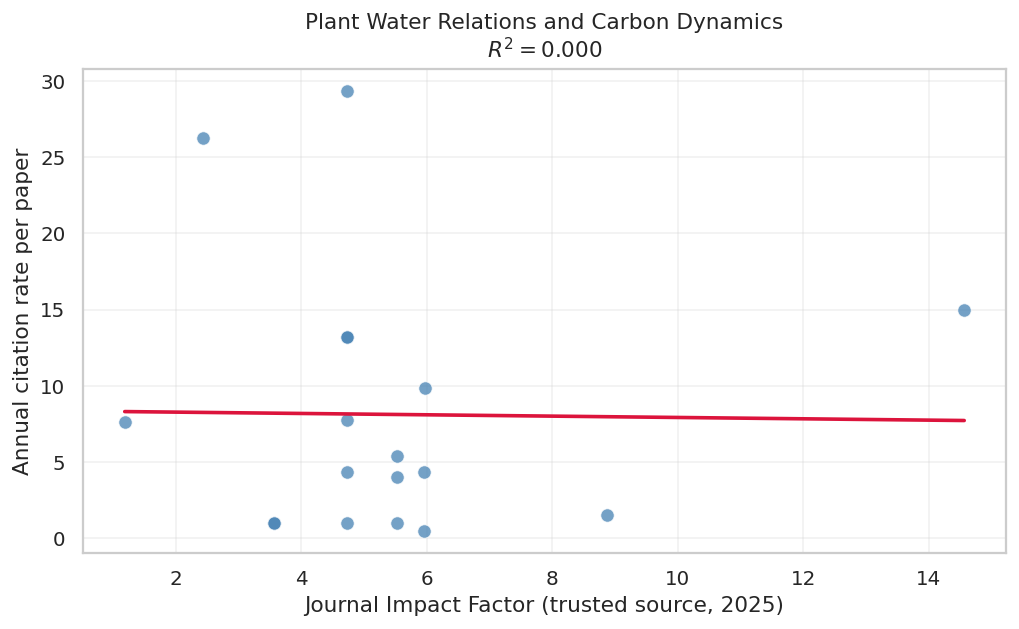

,topic,n_papers,slope,intercept,r_squared,p_value,mean_if,mean_annual_citation
0,Crop Yield and Soil Fertility,65,0.633372,3.906836,0.029666,0.170073,4.343222,6.657711
1,Remote Sensing in Agriculture,43,1.407882,6.123264,0.036179,0.221818,5.571263,13.966944
2,Climate change impacts on agriculture,42,5.717807,-17.695500,0.374344,0.000017,6.099898,17.182540
3,Soybean genetics and cultivation,29,0.130180,4.913810,0.002966,0.779012,4.169920,5.456650
4,Soil Carbon and Nitrogen Dynamics,23,3.332653,-7.491793,0.421105,0.000808,5.642136,11.311491
5,Plant Water Relations and Carbon Dynamics,18,-0.043808,8.361606,0.000206,0.954935,5.390358,8.125463


In [45]:
journal_if= JOURNAL_IF_2025
journal_if = journal_if.rename(columns={"impact_factor": "IF"})

current_year = pd.Timestamp.now().year
paper_df = (
    filtered_TargetA_df_corr[["article_id", "publication_year", TOPIC_COL, "journal_display_name", "total_citations"]]
    .dropna(subset=["article_id", "publication_year", TOPIC_COL, "journal_display_name", "total_citations"])
    .copy()
)
paper_df["paper_age_years"] = (current_year - paper_df["publication_year"]).clip(lower=1)
paper_df["annual_citation_rate"] = paper_df["total_citations"] / paper_df["paper_age_years"]
paper_df["journal_name_norm"] = (
    paper_df["journal_display_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

journal_if["journal_name_norm"] = (
    journal_if["journal_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

journal_if_clean = (
    journal_if[["journal_name_norm", "IF"]]
    .dropna(subset=["journal_name_norm", "IF"])
    .drop_duplicates(subset=["journal_name_norm"], keep="last")
)

paper_df = paper_df.merge(journal_if_clean, on="journal_name_norm", how="left")
paper_df = paper_df.dropna(subset=["IF", "annual_citation_rate", TOPIC_COL]).copy()

topic_counts = paper_df.groupby(TOPIC_COL)["article_id"].nunique().sort_values(ascending=False)
mean_papers_topics = float(topic_counts.mean()) if not topic_counts.empty else 0.0
threshold = mean_papers_topics + 5

topics_above_mean = topic_counts[topic_counts >= threshold].index.tolist()
print(f"Topics considered: {len(topic_counts)}")
print(f"Mean papers across topics: {mean_papers_topics:.2f}")
print(f"Filter threshold: mean + 5 = {threshold:.2f}")
print(f"Topics selected: {len(topics_above_mean)}")

summary_rows = []
if not topics_above_mean:
    print("No topics met the selection threshold.")
else:
    for topic in topics_above_mean:
        topic_df = paper_df[paper_df[TOPIC_COL] == topic].copy()
        topic_df = topic_df.dropna(subset=["IF", "annual_citation_rate"])

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(
            topic_df["IF"],
            topic_df["annual_citation_rate"],
            alpha=0.75,
            s=55,
            color="steelblue",
            edgecolors="white",
            linewidth=0.5,
        )

        slope = np.nan
        intercept = np.nan
        r_squared = np.nan
        p_value = np.nan

        x = topic_df["IF"].to_numpy(dtype=float)
        y = topic_df["annual_citation_rate"].to_numpy(dtype=float)

        if len(topic_df) >= 2 and np.unique(x).size >= 2 and np.unique(y).size >= 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            r_squared = r_value ** 2
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="crimson", linewidth=2)

        ax.set_title(f"{topic}\n$R^2 = {r_squared:.3f}$" if pd.notna(r_squared) else f"{topic}\n$R^2 = n/a$")
        ax.set_xlabel("Journal Impact Factor (trusted source, 2025)")
        ax.set_ylabel("Annual citation rate per paper")
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

        summary_rows.append(
            {
                "topic": topic,
                "n_papers": int(len(topic_df)),
                "slope": slope,
                "intercept": intercept,
                "r_squared": r_squared,
                "p_value": p_value,
                "mean_if": float(topic_df["IF"].mean()) if not topic_df.empty else np.nan,
                "mean_annual_citation": float(topic_df["annual_citation_rate"].mean()) if not topic_df.empty else np.nan,
            }
        )

summary_df = pd.DataFrame(summary_rows).sort_values(["n_papers", "r_squared"], ascending=[False, False])
display(summary_df)

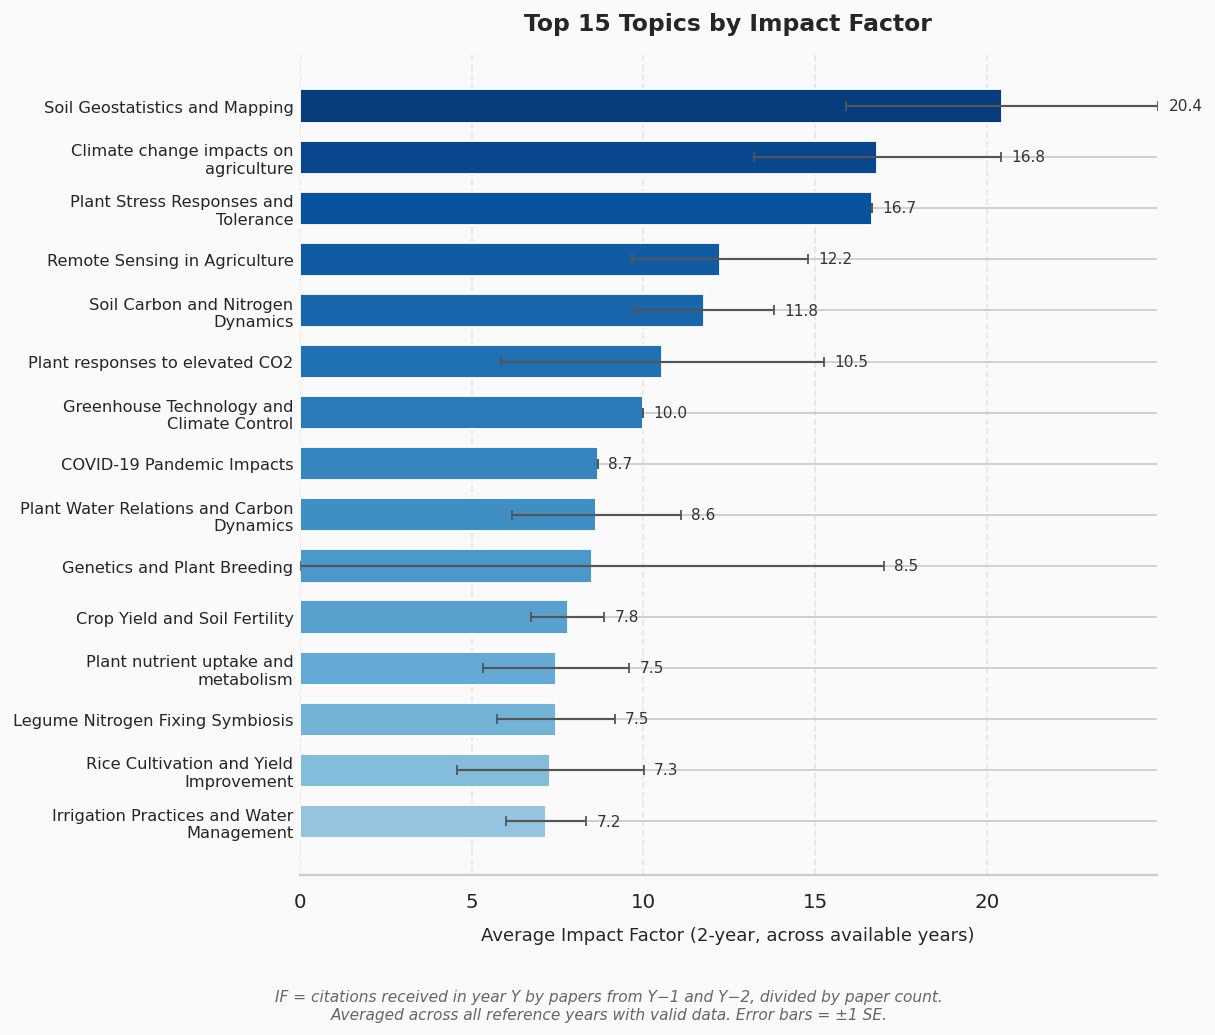

In [46]:
journal_if = compute_impact_factor(filtered_TargetA_df_corr, group_col="journal_display_name", min_papers=2)
topic_if   = compute_impact_factor(filtered_TargetA_df_corr, group_col="primary_topic",        min_papers=2)
 
def aggregate_if(df, group_col):
    g = (df.dropna(subset=["impact_factor"])
           .groupby(group_col)["impact_factor"]
           .agg(["mean", "std", "count"])
           .reset_index())
    g.columns = [group_col, "avg_if", "std_if", "n_years"]
    g["se"] = g["std_if"] / np.sqrt(g["n_years"])
    return g.sort_values("avg_if", ascending=False).head(15)
 
 
t_top = aggregate_if(topic_if, "primary_topic")
t_top = t_top.sort_values("avg_if")  # ascending so highest appears at top
 
n = len(t_top)
cmap = plt.cm.Blues
colors = [cmap(0.4 + 0.55 * (i / (n - 1))) for i in range(n)]
 
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")
 
ax.barh(
    range(n),
    t_top["avg_if"],
    color=colors,
    height=0.65,
    xerr=t_top["se"].fillna(0),
    error_kw=dict(ecolor="#555", capsize=3, lw=1.2),
)
 
labels = t_top["primary_topic"].str.wrap(32).tolist()
ax.set_yticks(range(n))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Average Impact Factor (2-year, across available years)", fontsize=10, labelpad=8)
ax.set_title("Top 15 Topics by Impact Factor", fontsize=13, fontweight="bold", pad=12)
 
for i, (val, se) in enumerate(zip(t_top["avg_if"], t_top["se"].fillna(0))):
    ax.text(val + se + 0.3, i, f"{val:.1f}", va="center", fontsize=8.5, color="#333")
 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, t_top["avg_if"].max() * 1.22)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
 
note = (
    "IF = citations received in year Y by papers from Y−1 and Y−2, divided by paper count.\n"
    "Averaged across all reference years with valid data. Error bars = ±1 SE."
)
fig.text(0.5, -0.02, note, ha="center", fontsize=8.5, color="#666", style="italic")
 
plt.tight_layout(pad=2.5)
plt.show()

Initial dataset size: 14858
Dataset size after filtering: 8360
Number of unique topics after filtering: 6
Number of unique topics in the top set: 6
Number of unique topics in the rest set: 6
Number of top papers: 33
Number of rest papers: 187
Eligible topics in top set: 3/6


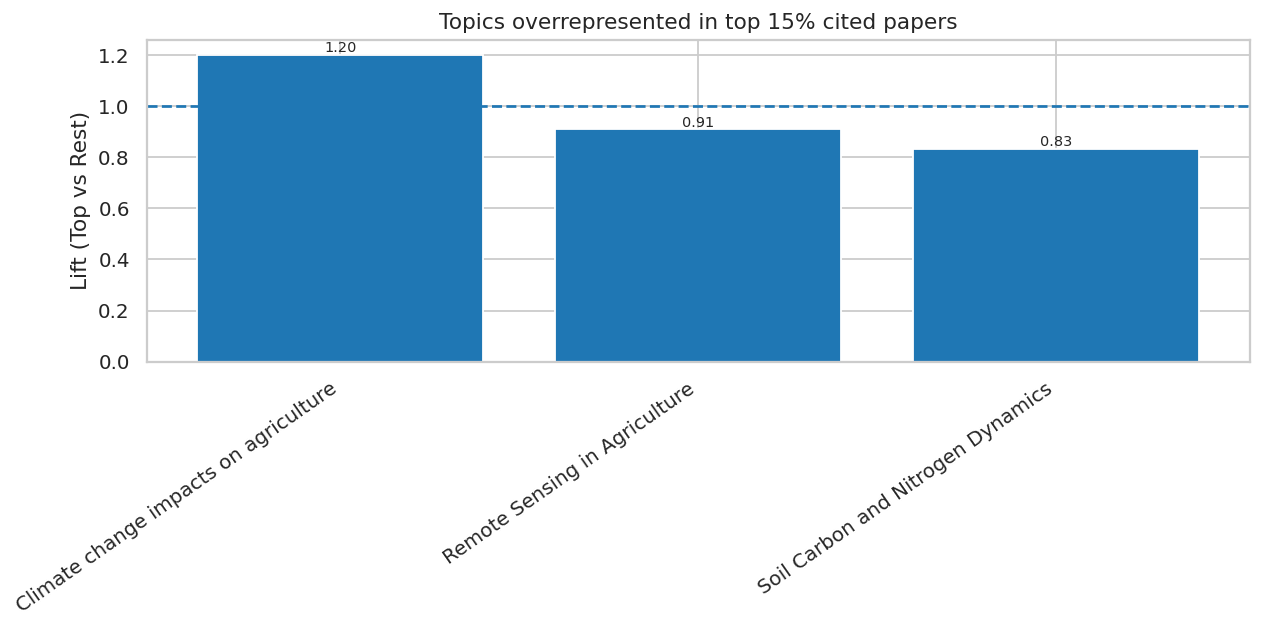

,topic,top_pct,rest_pct,lift,p_value,top_count,rest_count
0,Climate change impacts on agriculture,44.44,37.04,1.20,6.485e-01,12,30
1,Remote Sensing in Agriculture,37.04,40.74,0.91,9.096e-01,10,33
2,Soil Carbon and Nitrogen Dynamics,18.52,22.22,0.83,8.921e-01,5,18


In [47]:
# ── PARAMETERS ────────────────────────────────────────────────────────────────
TOP_PERCENTILE = 0.15   # top 15% most cited papers
MIN_COUNT = 15          # minimum papers per topic
TOP_K_PLOT = 10         # number of topics to display

# ── PREPARE DATA ──────────────────────────────────────────────────────────────
df = filtered_TargetA_df_corr.copy()
print(f"Initial dataset size: {df.size}")
# Remove missing
df = df.dropna(subset=[TOPIC_COL, "total_citations"])

# Filter low-frequency topics
topic_counts = df[TOPIC_COL].value_counts()
valid_topics = topic_counts[topic_counts >= MIN_COUNT].index
df = df[df[TOPIC_COL].isin(valid_topics)]
print(f"Dataset size after filtering: {df.size}")
print(f"Number of unique topics after filtering: {df[TOPIC_COL].nunique()}")

# ── DEFINE TOP PAPERS (percentile-based) ──────────────────────────────────────
threshold = df["total_citations"].quantile(1 - TOP_PERCENTILE)

top_df = df[df["total_citations"] >= threshold].copy()
print(f"Number of unique topics in the top set: {top_df[TOPIC_COL].nunique()}")

rest_df = df[df["total_citations"] < threshold].copy()
print(f"Number of unique topics in the rest set: {rest_df[TOPIC_COL].nunique()}")

print(f"Number of top papers: {top_df.shape[0]}")
print(f"Number of rest papers: {rest_df.shape[0]}")

#── FILTER TOPICS BY MEAN PAPERS IN TOP-CITED SET ────────────────────────────
top_counts_raw = top_df[TOPIC_COL].value_counts()
eligible_topics = top_counts_raw[top_counts_raw >= 5].index
print(
    f"Eligible topics in top set: "
    f"{len(eligible_topics)}/{len(top_counts_raw)}"
)

# Keep only eligible topics in both sets for a fair comparison
top_df = top_df[top_df[TOPIC_COL].isin(eligible_topics)].copy()
rest_df = rest_df[rest_df[TOPIC_COL].isin(eligible_topics)].copy()

if top_df.empty:
    print("No eligible top-cited topics after mean-paper filtering.")
    results_df = pd.DataFrame()
else:
    # ── DISTRIBUTIONS ─────────────────────────────────────────────────────────
    top_counts = top_df[TOPIC_COL].value_counts()
    rest_counts = rest_df[TOPIC_COL].value_counts()

    all_topics = sorted(top_counts.index)

    top_pct = (top_counts.reindex(all_topics, fill_value=0) / len(top_df)) * 100
    rest_den = len(rest_df) if len(rest_df) > 0 else np.nan
    rest_pct = (rest_counts.reindex(all_topics, fill_value=0) / rest_den) * 100

    # ── LIFT (overrepresentation) ─────────────────────────────────────────────
    lift = (top_pct / rest_pct).replace([np.inf, -np.inf], np.nan)

    # ── STATISTICAL SIGNIFICANCE (chi-square) ─────────────────────────────────
    results = []
    for topic in all_topics:
        a = top_counts.get(topic, 0)
        b = len(top_df) - a
        c = rest_counts.get(topic, 0)
        d = len(rest_df) - c

        table = [[a, b], [c, d]]

        try:
            chi2, p, _, _ = chi2_contingency(table)
        except Exception:
            p = np.nan

        results.append({
            "topic": topic,
            "top_pct": top_pct[topic],
            "rest_pct": rest_pct[topic],
            "lift": lift[topic],
            "p_value": p,
            "top_count": a,
            "rest_count": c
        })

    results_df = pd.DataFrame(results)

if not results_df.empty:
    # ── CLEAN + SORT ──────────────────────────────────────────────────────────
    results_df = results_df.dropna(subset=["lift"])
    results_df = results_df.sort_values("lift", ascending=False)

    # Keep top K for visualization
    plot_df = results_df.head(TOP_K_PLOT)

    # ── PLOT: LIFT (main result) ──────────────────────────────────────────────
    plt.figure()
    plt.bar(plot_df["topic"], plot_df["lift"])

    # Baseline
    plt.axhline(1, linestyle="--")

    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Lift (Top vs Rest)")
    plt.title(f"Topics overrepresented in top {int(TOP_PERCENTILE*100)}% cited papers")

    # Annotate values
    for i, v in enumerate(plot_df["lift"]):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── OPTIONAL: PRINT TABLE ─────────────────────────────────────────────────
    display(
        results_df.head(15).assign(
            top_pct=lambda x: x["top_pct"].round(2),
            rest_pct=lambda x: x["rest_pct"].round(2),
            lift=lambda x: x["lift"].round(2),
            p_value=lambda v: v["p_value"].apply(
                lambda p: f"{p:.3e}" if pd.notnull(p) else "nan"
            )
        )
    )
else:
    print("No topic lift results to display after filtering.")

# How much more likely is this topic to appear in top 10% cited papers compared to the rest?


# Journal section

In [48]:
# ---- Target authors (corresponding): journal citation analysis (prep) ----
journal_col = "journal_display_name"
df_jnl = (
    filtered_TargetA_df_corr
    .dropna(subset=[journal_col, "publication_year"])
    .copy()
)
df_jnl["publication_year"] = df_jnl["publication_year"].astype(int)

# Category eligibility (across all years combined): papers >= floor(mean) + 1
df_jnl, journal_paper_counts, eligible_journals_idx, jnl_min_papers, _ = filter_categories_by_mean_plus_one(
    df_jnl,
    journal_col,
    paper_id_col="article_id",
    label="journals:calendar-year-avg",
)

cit_cols = [c for c in df_jnl.columns if c.startswith("citations_year_")]

has_jnl_data = False
melted_jnl = pd.DataFrame()
jnl_year_stats = pd.DataFrame()
per_year_top10 = pd.DataFrame()
top_journals_overall = []
journal_color = {}
jnl_impact = pd.DataFrame()
top3_journals = []
top_authors_by_journal = pd.DataFrame()
jnl_author_year = pd.DataFrame()
dominant_journal_by_year = pd.DataFrame()

if not cit_cols or df_jnl.empty:
    print(f"No citations_year_* columns found or journal data is empty after threshold filtering (>= {jnl_min_papers} papers).")
else:
    melted_jnl = (
        df_jnl[["article_id", "queried_author", "publication_year", journal_col] + cit_cols]
        .melt(
            id_vars=["article_id", "queried_author", "publication_year", journal_col],
            value_vars=cit_cols,
            var_name="cit_col",
            value_name="citations",
        )
    )
    melted_jnl["offset"] = melted_jnl["cit_col"].str.extract(r"(\d+)$").astype(int)
    melted_jnl["calendar_year"] = melted_jnl["publication_year"].astype(int) + melted_jnl["offset"]
    melted_jnl["citations"] = melted_jnl["citations"].fillna(0)

    start_year = 2020
    end_year = 2025
    melted_jnl = melted_jnl[(melted_jnl["calendar_year"] >= start_year) & (melted_jnl["calendar_year"] <= end_year)]
    if melted_jnl.empty:
        print("No journal citations found in the 2020-2025 window.")
    else:
        has_jnl_data = True
        jnl_year_stats = (
            melted_jnl.groupby(["calendar_year", journal_col])
            .agg(
                total_citations=("citations", "sum"),
                n_papers=("article_id", "nunique"),
            )
            .reset_index()
        )
        jnl_year_stats["avg_citations_per_paper"] = (
            jnl_year_stats["total_citations"] / jnl_year_stats["n_papers"].where(jnl_year_stats["n_papers"] > 0)
        )

        per_year_top10 = (
            jnl_year_stats
            .sort_values(["calendar_year", "total_citations", journal_col], ascending=[True, False, True])
            .groupby("calendar_year")
            .head(10)
            .reset_index(drop=True)
        )
        top_journals_overall = (
            jnl_year_stats.groupby(journal_col)["total_citations"]
            .sum()
            .nlargest(10)
            .index.tolist()
        )
        colors = sns.color_palette("tab10", n_colors=max(1, len(top_journals_overall)))
        journal_color = dict(zip(top_journals_overall, colors))

        jnl_impact = (
            jnl_year_stats.groupby(journal_col)
            .agg(
                total_citations=("total_citations", "sum"),
                n_papers=("n_papers", "sum"),
            )
            .reset_index()
        )
        jnl_impact["avg_citations_per_paper"] = (
            jnl_impact["total_citations"] / jnl_impact["n_papers"].where(jnl_impact["n_papers"] > 0)
        )
        jnl_impact["avg_citations_per_year"] = jnl_impact["total_citations"] / (end_year - start_year + 1)
        jnl_impact = jnl_impact.sort_values("total_citations", ascending=False)

        top3_journals = jnl_impact[journal_col].head(3).tolist()
        df_jnl_author = (
            filtered_TargetA_df_corr
            .dropna(subset=[journal_col, "queried_author"])
            .copy()
        )
        df_jnl_author = df_jnl_author[df_jnl_author[journal_col].isin(eligible_journals_idx)]
        df_jnl_author["total_citations"] = df_jnl_author["total_citations"].fillna(0)
        top_authors_by_journal = (
            df_jnl_author[df_jnl_author[journal_col].isin(top3_journals)]
            .groupby([journal_col, "queried_author"])
            .agg(
                n_papers=("article_id", "nunique"),
                total_citations=("total_citations", "sum"),
            )
            .reset_index()
            .sort_values([journal_col, "total_citations", "n_papers"], ascending=[True, False, False])
        )
        top_authors_by_journal = (
            top_authors_by_journal
            .groupby(journal_col)
            .head(3)
            .reset_index(drop=True)
        )

        jnl_author_year = (
            melted_jnl.groupby(["queried_author", "calendar_year", journal_col])
            .agg(
                total_citations=("citations", "sum"),
                n_papers=("article_id", "nunique"),
            )
            .reset_index()
        )
        dominant_journal_by_year = (
            jnl_author_year
            .sort_values(
                ["queried_author", "calendar_year", "total_citations", "n_papers", journal_col],
                ascending=[True, True, False, False, True],
            )
            .groupby(["queried_author", "calendar_year"])
            .head(1)
            .rename(columns={journal_col: "top_journal"})
            .reset_index(drop=True)
        )

[journals:calendar-year-avg] mean papers=3.96, threshold=4, kept categories=23/96


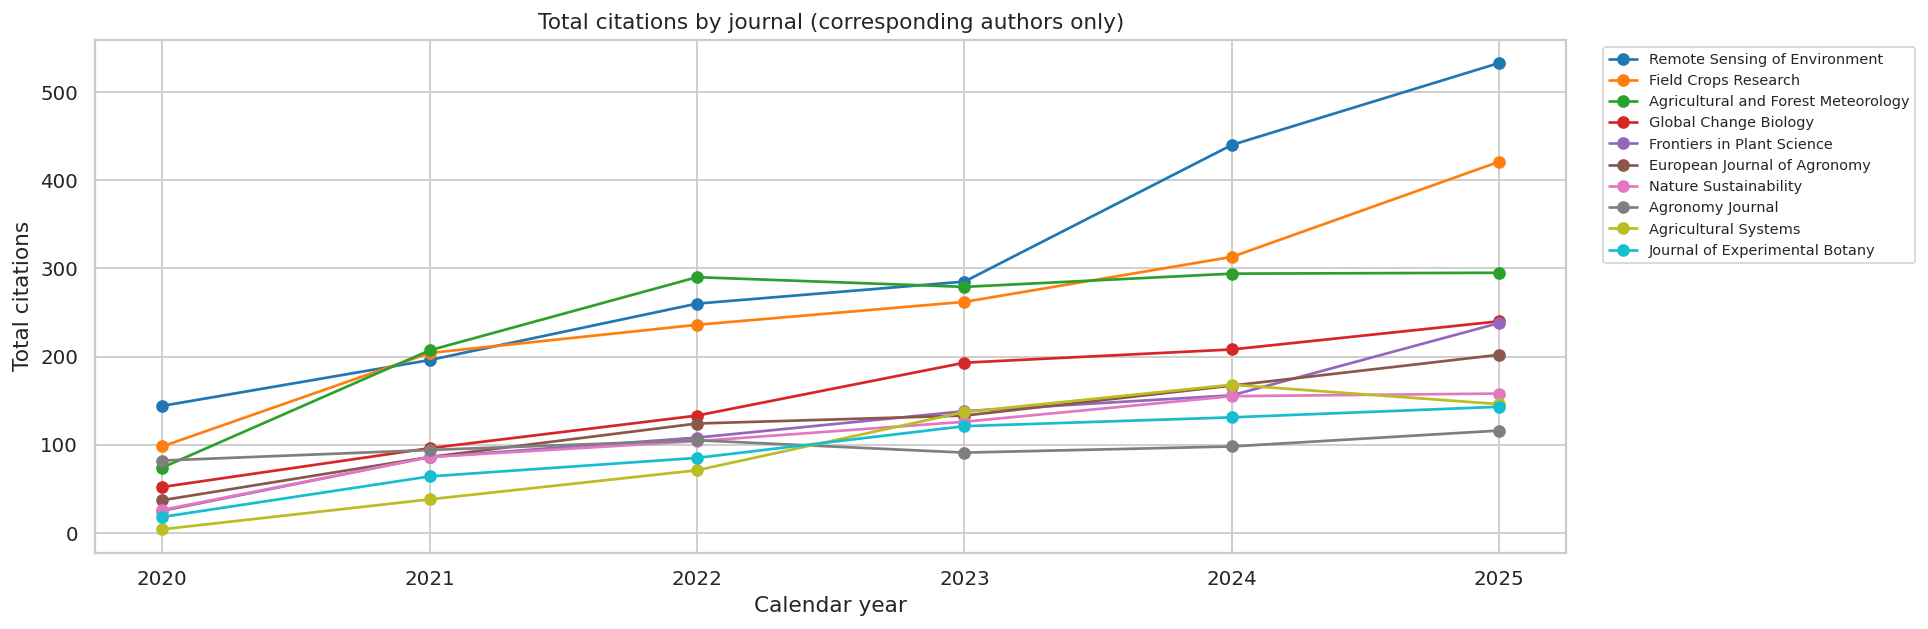

In [49]:
# ---- Total citations per year (top journals overall) ----
if not has_jnl_data or not top_journals_overall:
    print("No journal trend data to display.")
else:
    pivot_total = (
        jnl_year_stats[jnl_year_stats[journal_col].isin(top_journals_overall)]
        .pivot_table(index="calendar_year", columns=journal_col, values="total_citations", fill_value=0)
    )
    pivot_total = pivot_total[top_journals_overall]
    fig, ax = plt.subplots(figsize=(15, 5))
    for journal in top_journals_overall:
        ax.plot(
            pivot_total.index,
            pivot_total[journal],
            marker="o",
            label=journal,
            color=journal_color.get(journal),
        )
    ax.set_title("Total citations by journal (corresponding authors only)")
    ax.set_xlabel("Calendar year")
    ax.set_ylabel("Total citations")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

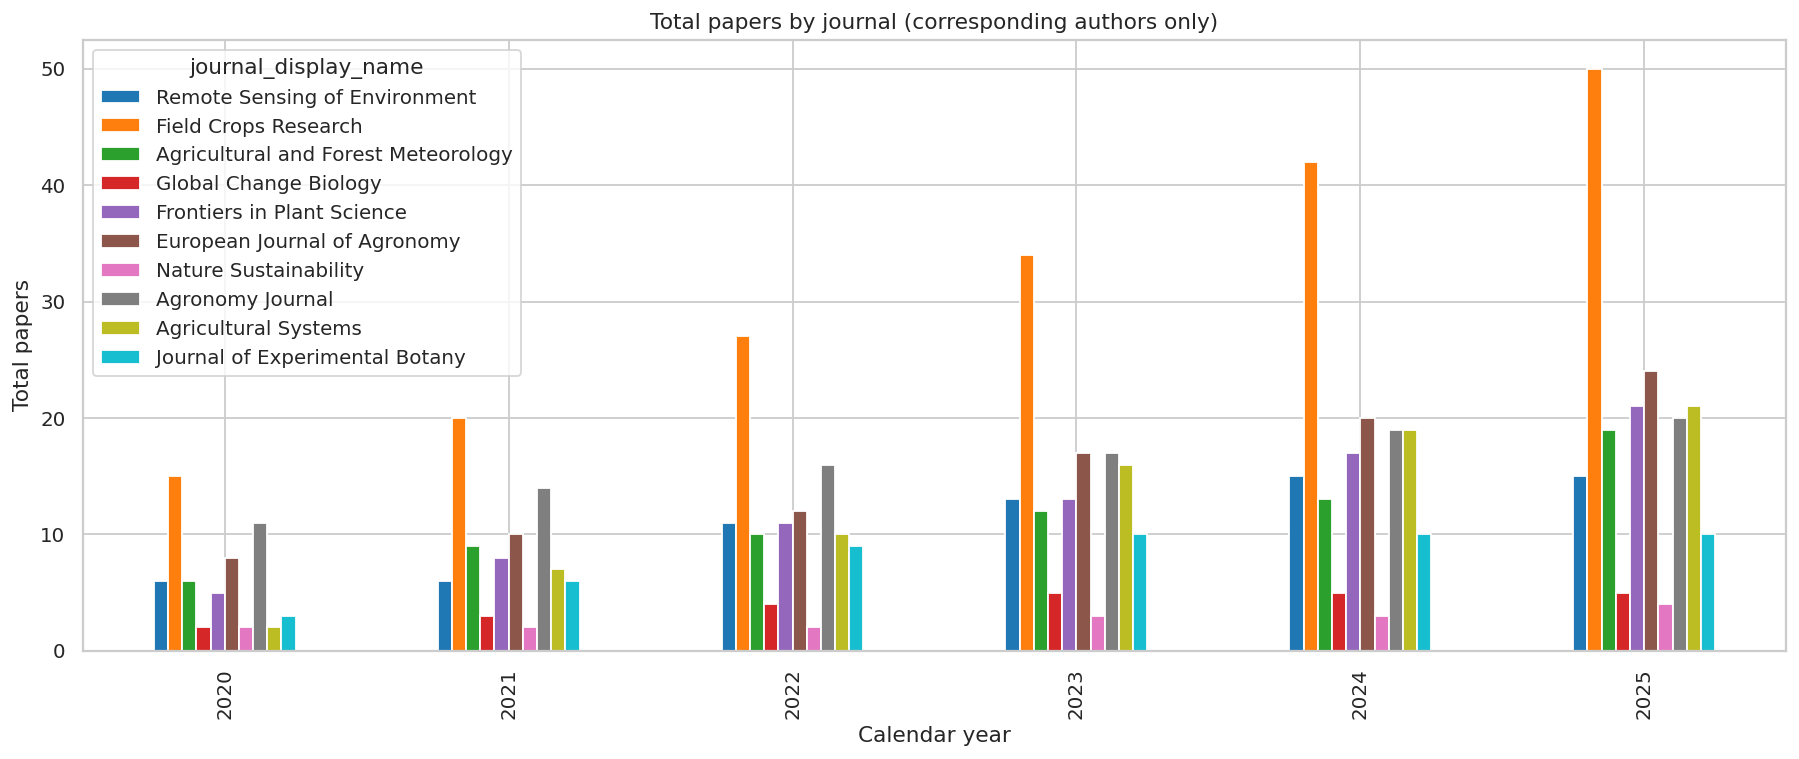

In [50]:
# ---- Total papers per year (top journals overall) ----
if not has_jnl_data or not top_journals_overall:
    print("No journal paper counts to display.")
else:
    pivot_papers = (
        jnl_year_stats[jnl_year_stats[journal_col].isin(top_journals_overall)]
        .pivot_table(index="calendar_year", columns=journal_col, values="n_papers", fill_value=0)
    )
    pivot_papers = pivot_papers[top_journals_overall]
    pivot_papers.plot(
        kind="bar",
        stacked=False,
        figsize=(14, 6),
        color=[journal_color[j] for j in top_journals_overall],
    )
    plt.title("Total papers by journal (corresponding authors only)")
    plt.xlabel("Calendar year")
    plt.ylabel("Total papers")
    plt.tight_layout()
    plt.show()

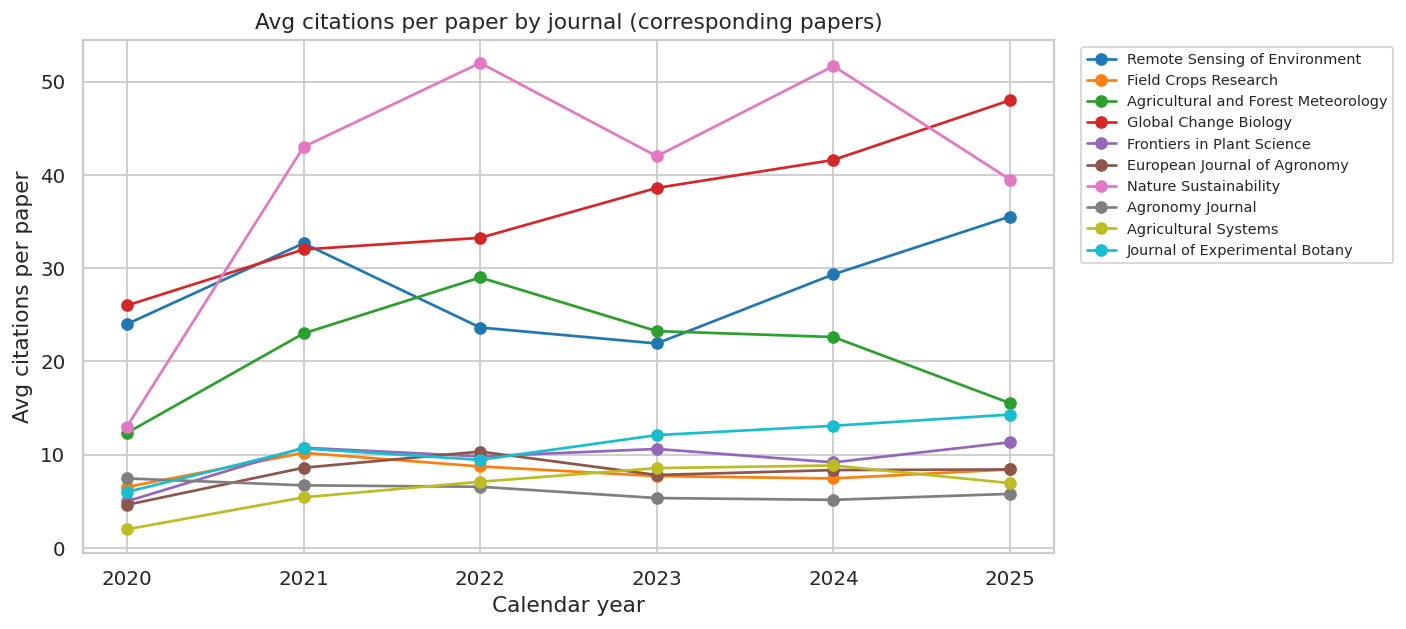

In [51]:
# ---- Avg citations per paper per year (top journals overall) ----
if not has_jnl_data or not top_journals_overall:
    print("No journal trend data to display.")
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for journal in top_journals_overall:
        grp = (
            jnl_year_stats[jnl_year_stats[journal_col] == journal]
            .sort_values("calendar_year")
        )
        ax.plot(
            grp["calendar_year"],
            grp["avg_citations_per_paper"],
            marker="o",
            label=journal,
            color=journal_color.get(journal),
        )
    ax.set_title("Avg citations per paper by journal (corresponding papers)")
    ax.set_xlabel("Calendar year")
    ax.set_ylabel("Avg citations per paper")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

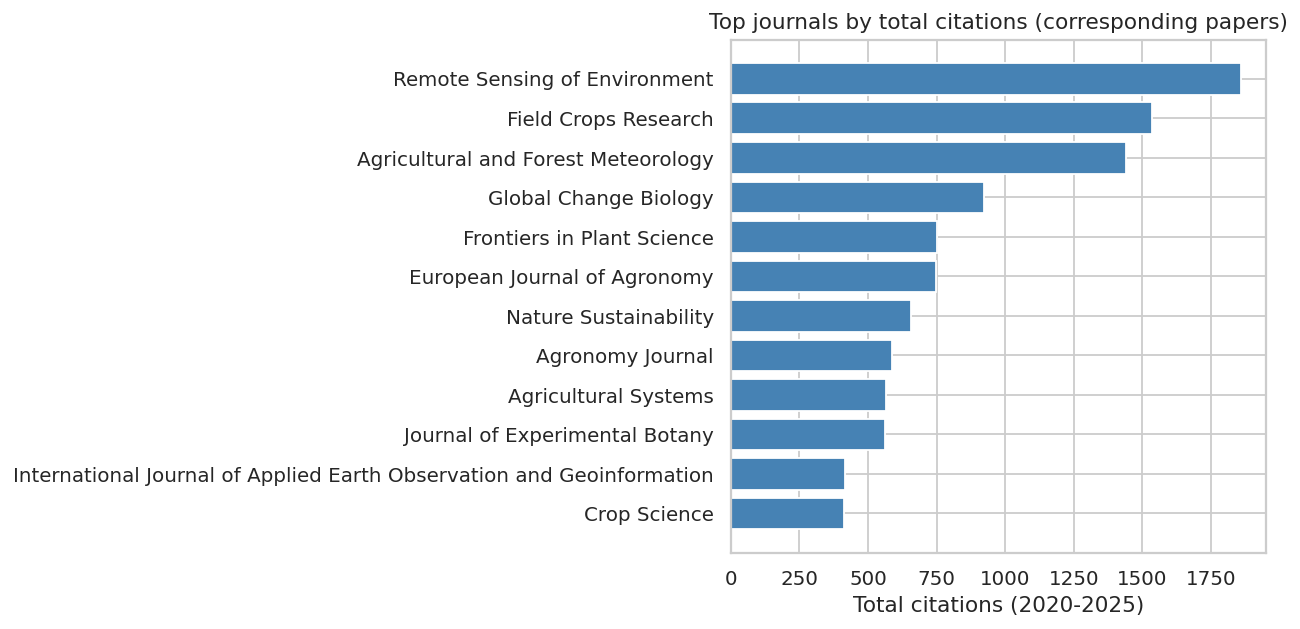

,journal_display_name,total_citations,n_papers,avg_citations_per_paper,avg_citations_per_year
21,Remote Sensing of Environment,1858.0,66,28.151515,309.666667
8,Field Crops Research,1534.0,188,8.159574,255.666667
2,Agricultural and Forest Meteorology,1439.0,69,20.855072,239.833333
11,Global Change Biology,922.0,24,38.416667,153.666667
9,Frontiers in Plant Science,751.0,75,10.013333,125.166667
7,European Journal of Agronomy,749.0,91,8.230769,124.833333
17,Nature Sustainability,655.0,16,40.937500,109.166667
3,Agronomy Journal,586.0,97,6.041237,97.666667
0,Agricultural Systems,564.0,75,7.520000,94.000000
14,Journal of Experimental Botany,562.0,48,11.708333,93.666667


In [52]:
# ---- Journal impact summary (2020-2025) ----
if not has_jnl_data or jnl_impact.empty:
    print("No journal impact data to display.")
else:
    plt.figure(figsize=(10, 5))
    plt.barh(
        jnl_impact[journal_col].head(12),
        jnl_impact["total_citations"].head(12),
        color="steelblue",
    )
    plt.xlabel("Total citations (2020-2025)")
    plt.title("Top journals by total citations (corresponding papers)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    display(jnl_impact.head(12))
    

In [53]:
# ---- Top 3 journals and top authors (all years) ----
if not has_jnl_data or jnl_impact.empty:
    print("No journal impact data to display.")
else:
    print("Top 3 journals by total citations (2020-2025)")
    display(jnl_impact.head(3)[[journal_col, "total_citations", "n_papers", "avg_citations_per_paper"]])
    if top_authors_by_journal.empty:
        print("No author-level journal data to display.")
    else:
        print("Top 3 authors by total citations within each top journal (all years)")
        display(top_authors_by_journal)

Top 3 journals by total citations (2020-2025)


,journal_display_name,total_citations,n_papers,avg_citations_per_paper
21,Remote Sensing of Environment,1858.0,66,28.151515
8,Field Crops Research,1534.0,188,8.159574
2,Agricultural and Forest Meteorology,1439.0,69,20.855072


Top 3 authors by total citations within each top journal (all years)


,journal_display_name,queried_author,n_papers,total_citations
0,Agricultural and Forest Meteorology,Kaiyu,10,864
1,Agricultural and Forest Meteorology,Ciampitti,6,442
2,Agricultural and Forest Meteorology,Rattalino,2,135
3,Field Crops Research,Ciampitti,18,466
4,Field Crops Research,Archontoulis,11,433
5,Field Crops Research,Grassini,9,323
6,Remote Sensing of Environment,Kaiyu,11,1272
7,Remote Sensing of Environment,Lobell,3,732
8,Remote Sensing of Environment,Basso,1,72


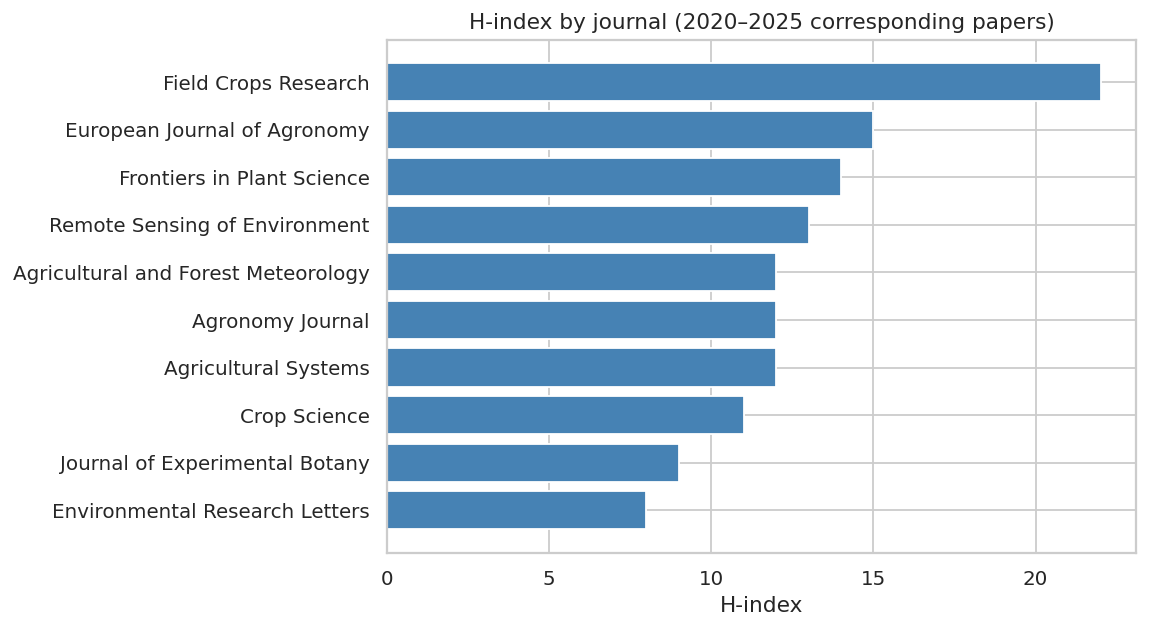

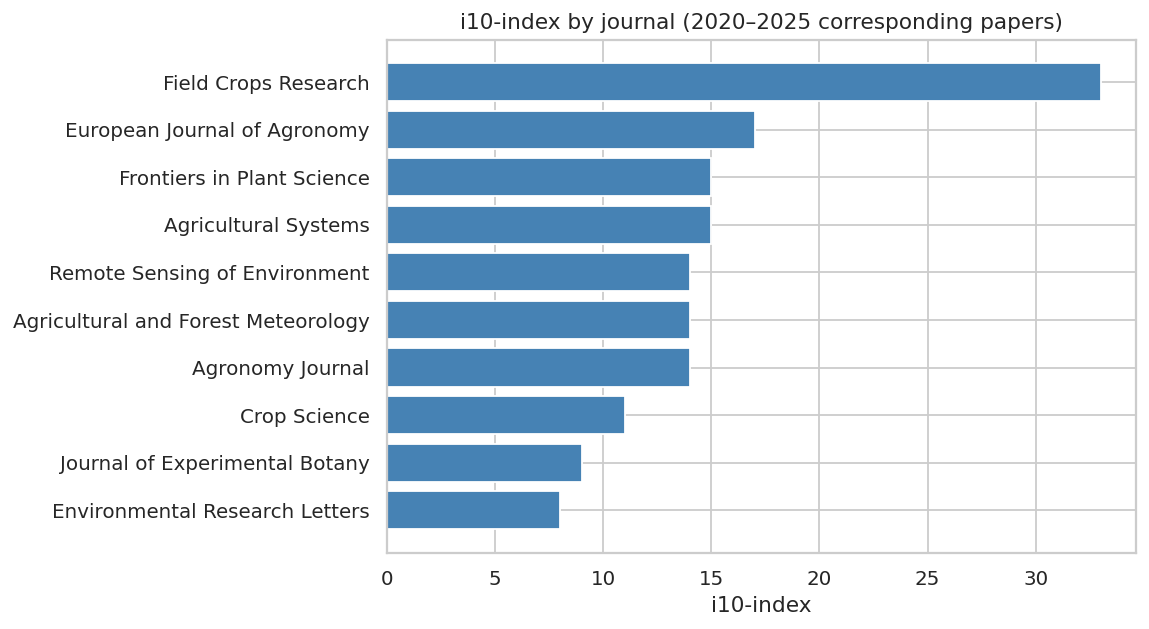

In [61]:

journal_metrics = calculate_group_metrics(filtered_TargetA_df_corr, group_col='journal_display_name', citations_col='total_citations')

journal_metrics_h = (
    journal_metrics.dropna(subset=["h_index"])
    .sort_values("h_index", ascending=True)
    .tail(10)
)
plt.figure(figsize=(9, 5))
plt.barh(journal_metrics_h["journal_display_name"], journal_metrics_h["h_index"], color="steelblue")
plt.xlabel("H-index")
plt.title("H-index by journal (2020–2025 corresponding papers)")
plt.tight_layout()
plt.show()

journal_metrics_i10 = (
    journal_metrics.dropna(subset=["i10_index"])
    .sort_values("i10_index", ascending=True)
    .tail(10)
)
plt.figure(figsize=(9, 5))
plt.barh(journal_metrics_i10["journal_display_name"], journal_metrics_i10["i10_index"], color="steelblue")
plt.xlabel("i10-index")
plt.title("i10-index by journal (2020–2025 corresponding papers)")
plt.tight_layout()
plt.show()

Initial dataset size: 14858
Dataset size after filtering: 7258
Number of unique journals after filtering: 8
Number of unique journals in the top set: 8
Number of unique journals in the rest set: 8
Number of top papers: 29
Number of rest papers: 162
Eligible journals in top set: 2/8


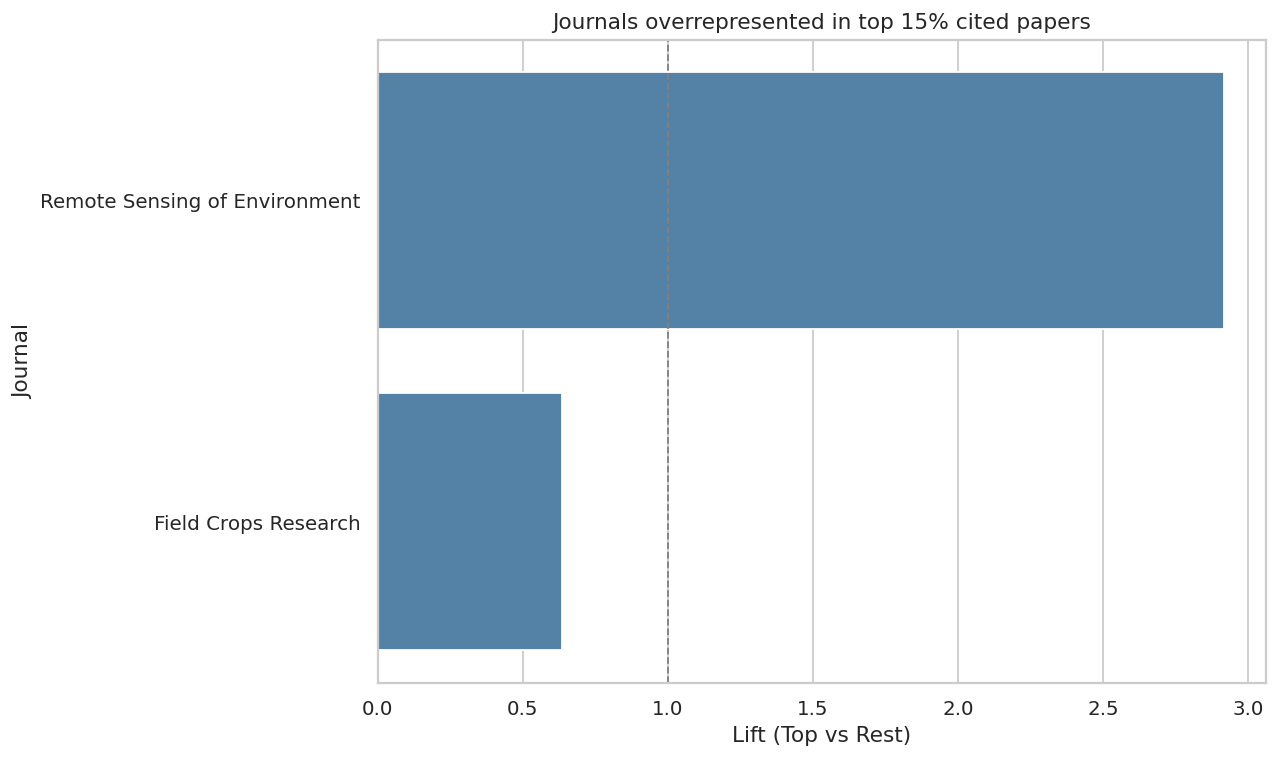

,journal,top_pct,rest_pct,lift,p_value,top_count,rest_count
1,Remote Sensing of Environment,46.67,16.0,2.92,3.375e-02,7,8
0,Field Crops Research,53.33,84.0,0.63,3.375e-02,8,42


In [63]:
# ── PARAMETERS ────────────────────────────────────────────────────────────────
JOURNAL_TOP_PERCENTILE = 0.15   # top 15% most cited papers
JOURNAL_MIN_COUNT = 15          # minimum papers per journal
JOURNAL_TOP_K_PLOT = 10         # number of journals to display

# ── PREPARE DATA ──────────────────────────────────────────────────────────────
df_journal_lift = filtered_TargetA_df_corr.copy()
print(f"Initial dataset size: {df_journal_lift.size}")

# Remove missing
df_journal_lift = df_journal_lift.dropna(subset=[journal_col, "total_citations"])

# Filter low-frequency journals
journal_counts = df_journal_lift[journal_col].value_counts()
valid_journals = journal_counts[journal_counts >= JOURNAL_MIN_COUNT].index
df_journal_lift = df_journal_lift[df_journal_lift[journal_col].isin(valid_journals)]
print(f"Dataset size after filtering: {df_journal_lift.size}")
print(f"Number of unique journals after filtering: {df_journal_lift[journal_col].nunique()}")

# ── DEFINE TOP PAPERS (percentile-based) ──────────────────────────────────────
journal_threshold = df_journal_lift["total_citations"].quantile(1 - JOURNAL_TOP_PERCENTILE)

journal_top_df = df_journal_lift[df_journal_lift["total_citations"] >= journal_threshold].copy()
print(f"Number of unique journals in the top set: {journal_top_df[journal_col].nunique()}")

journal_rest_df = df_journal_lift[df_journal_lift["total_citations"] < journal_threshold].copy()
print(f"Number of unique journals in the rest set: {journal_rest_df[journal_col].nunique()}")

print(f"Number of top papers: {journal_top_df.shape[0]}")
print(f"Number of rest papers: {journal_rest_df.shape[0]}")

# ── FILTER JOURNALS BY MIN PAPERS IN TOP-CITED SET ───────────────────────────
journal_top_counts_raw = journal_top_df[journal_col].value_counts()
eligible_journals = journal_top_counts_raw[journal_top_counts_raw >= 5].index
print(
    f"Eligible journals in top set: "
    f"{len(eligible_journals)}/{len(journal_top_counts_raw)}"
)

# Keep only eligible journals in both sets for a fair comparison
journal_top_df = journal_top_df[journal_top_df[journal_col].isin(eligible_journals)].copy()
journal_rest_df = journal_rest_df[journal_rest_df[journal_col].isin(eligible_journals)].copy()

if journal_top_df.empty:
    print("No eligible top-cited journals after filtering.")
    journal_results_df = pd.DataFrame()
else:
    # ── DISTRIBUTIONS ─────────────────────────────────────────────────────────
    journal_top_counts = journal_top_df[journal_col].value_counts()
    journal_rest_counts = journal_rest_df[journal_col].value_counts()

    all_journals = sorted(journal_top_counts.index)

    journal_top_pct = (journal_top_counts.reindex(all_journals, fill_value=0) / len(journal_top_df)) * 100
    journal_rest_den = len(journal_rest_df) if len(journal_rest_df) > 0 else np.nan
    journal_rest_pct = (journal_rest_counts.reindex(all_journals, fill_value=0) / journal_rest_den) * 100

    # ── LIFT (overrepresentation) ─────────────────────────────────────────────
    journal_lift = (journal_top_pct / journal_rest_pct).replace([np.inf, -np.inf], np.nan)

    # ── STATISTICAL SIGNIFICANCE (chi-square) ─────────────────────────────────
    journal_results = []
    for jnl in all_journals:
        a = journal_top_counts.get(jnl, 0)
        b = len(journal_top_df) - a
        c = journal_rest_counts.get(jnl, 0)
        d = len(journal_rest_df) - c

        table = [[a, b], [c, d]]

        try:
            chi2, p, _, _ = chi2_contingency(table)
        except Exception:
            p = np.nan

        journal_results.append({
            "journal": jnl,
            "top_pct": journal_top_pct[jnl],
            "rest_pct": journal_rest_pct[jnl],
            "lift": journal_lift[jnl],
            "p_value": p,
            "top_count": a,
            "rest_count": c,
        })

    journal_results_df = pd.DataFrame(journal_results)

if not journal_results_df.empty:
    # ── CLEAN + SORT ──────────────────────────────────────────────────────────
    journal_results_df = journal_results_df.dropna(subset=["lift"]).sort_values("lift", ascending=False)

    # Keep top K for visualization
    journal_plot_df = journal_results_df.head(JOURNAL_TOP_K_PLOT)

    # ── PLOT: LIFT (main result) ──────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=journal_plot_df,
        x="lift",
        y="journal",
        color="steelblue",
    )
    plt.axvline(1, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Lift (Top vs Rest)")
    plt.ylabel("Journal")
    plt.title(
        f"Journals overrepresented in top {int(JOURNAL_TOP_PERCENTILE * 100)}% cited papers"
    )
    plt.tight_layout()
    plt.show()

    # ── OPTIONAL: PRINT TABLE ─────────────────────────────────────────────────
    display(
        journal_results_df.head(15).assign(
            top_pct=lambda x: x["top_pct"].round(2),
            rest_pct=lambda x: x["rest_pct"].round(2),
            lift=lambda x: x["lift"].round(2),
            p_value=lambda v: v["p_value"].apply(
                lambda p: f"{p:.3e}" if pd.notnull(p) else "nan"
            ),
        )
    )
else:
    print("No journal lift results to display after filtering.")

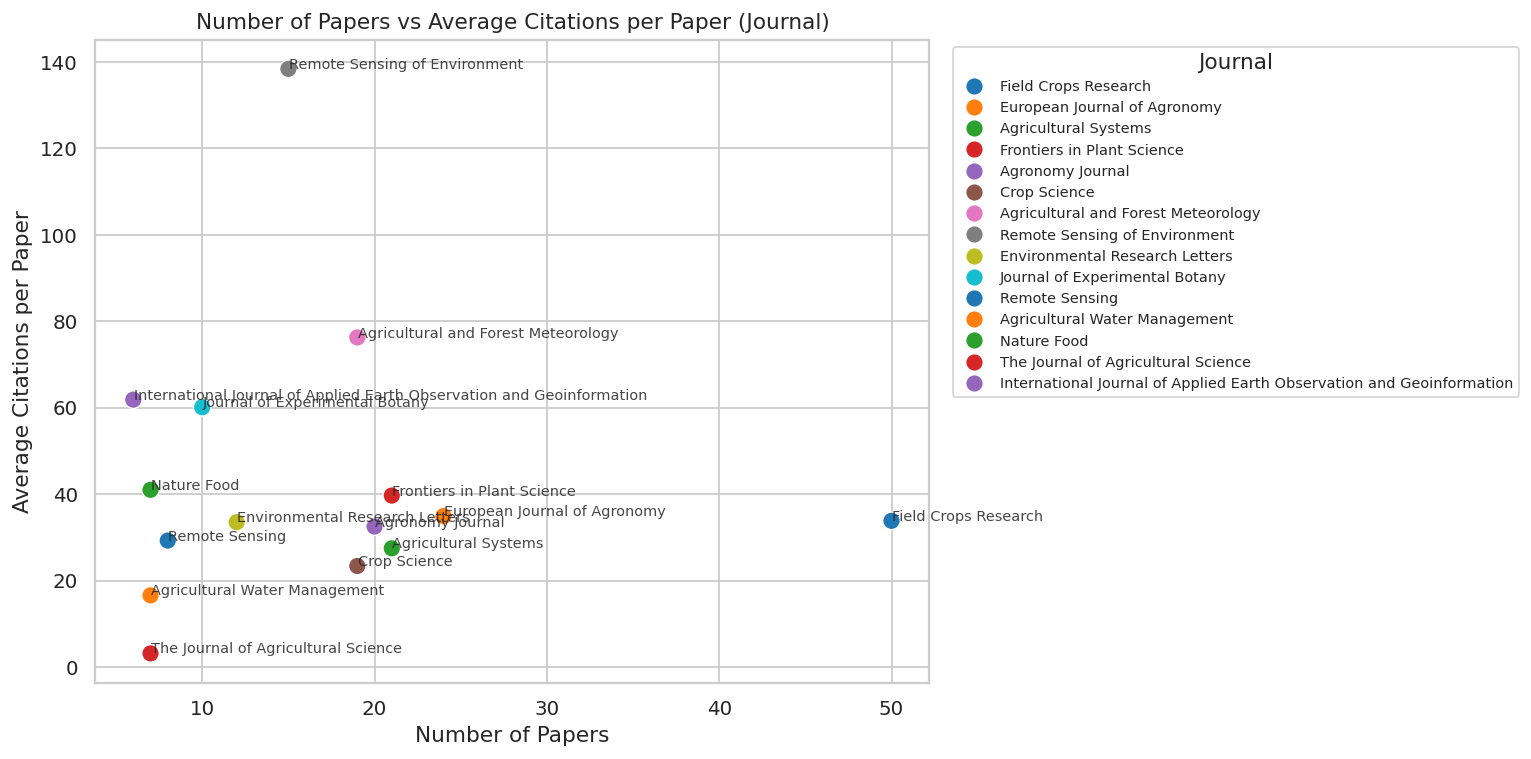

Mean papers across all journals: 3.96


,journal_display_name,n_papers,avg_citations_per_paper
27,Field Crops Research,50,33.820000
24,European Journal of Agronomy,24,34.916667
1,Agricultural Systems,21,27.454545
31,Frontiers in Plant Science,21,39.666667
6,Agronomy Journal,20,32.500000
16,Crop Science,19,23.368421
3,Agricultural and Forest Meteorology,19,76.250000
73,Remote Sensing of Environment,15,138.400000
20,Environmental Research Letters,12,33.500000
46,Journal of Experimental Botany,10,60.100000


In [56]:
JOURNAL_COL = "journal_display_name"
JOURNAL_LEVEL_LABEL = "Journal"

journal_summary = (
    filtered_TargetA_df_corr[[JOURNAL_COL, "article_id", "total_citations"]]
    .dropna(subset=[JOURNAL_COL, "article_id", "total_citations"])
    .groupby(JOURNAL_COL, as_index=False)
    .agg(
        n_papers=("article_id", "nunique"),
        avg_citations_per_paper=("total_citations", "mean"),
    )
)

mean_papers_journals = journal_summary["n_papers"].mean()
journal_summary = (
    journal_summary[journal_summary["n_papers"] >= mean_papers_journals +2]
    .sort_values("n_papers", ascending=False)
)

journals_order = journal_summary[JOURNAL_COL].tolist()
base_palette = sns.color_palette("tab10", n_colors=max(len(journals_order), 10))




plt.figure(figsize=(12, 6))
ax = sns.scatterplot(
    data=journal_summary,
    x="n_papers",
    y="avg_citations_per_paper",
    hue=JOURNAL_COL,
    palette=sns.color_palette("tab10", n_colors=len(journals_order)),
    s=95,
)

for _, row in journal_summary.iterrows():
    plt.text(
        row["n_papers"] + 0.03,
        row["avg_citations_per_paper"] + 0.03,
        str(row[JOURNAL_COL]),
        fontsize=8,
        alpha=0.85,
    )

plt.title(f"Number of Papers vs Average Citations per Paper ({JOURNAL_LEVEL_LABEL})")
plt.xlabel("Number of Papers")
plt.ylabel("Average Citations per Paper")
ax.legend(title=JOURNAL_LEVEL_LABEL, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Mean papers across all journals: {mean_papers_journals:.2f}")
journal_summary

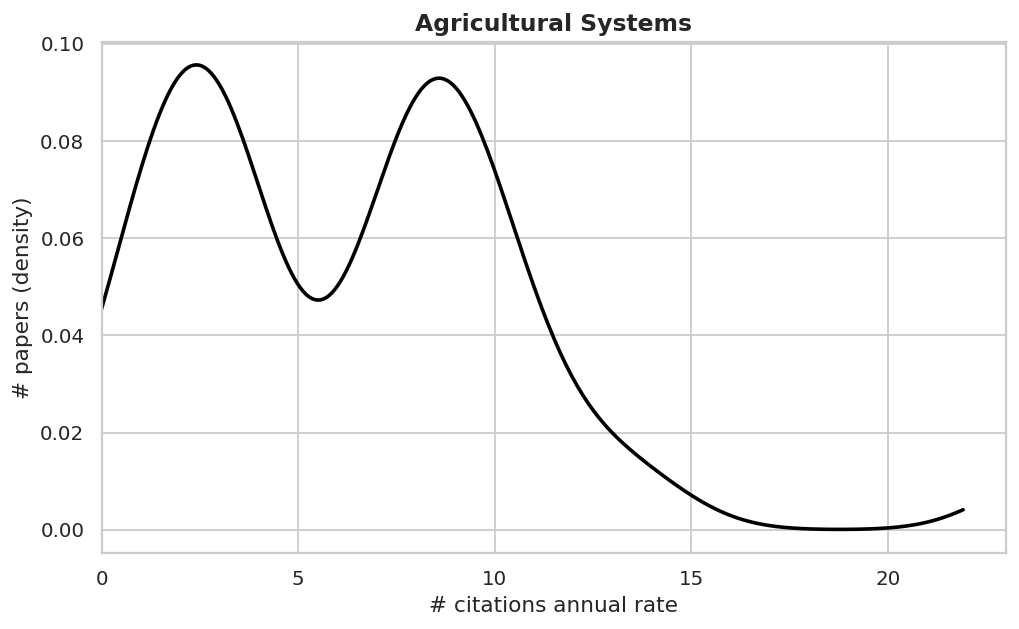

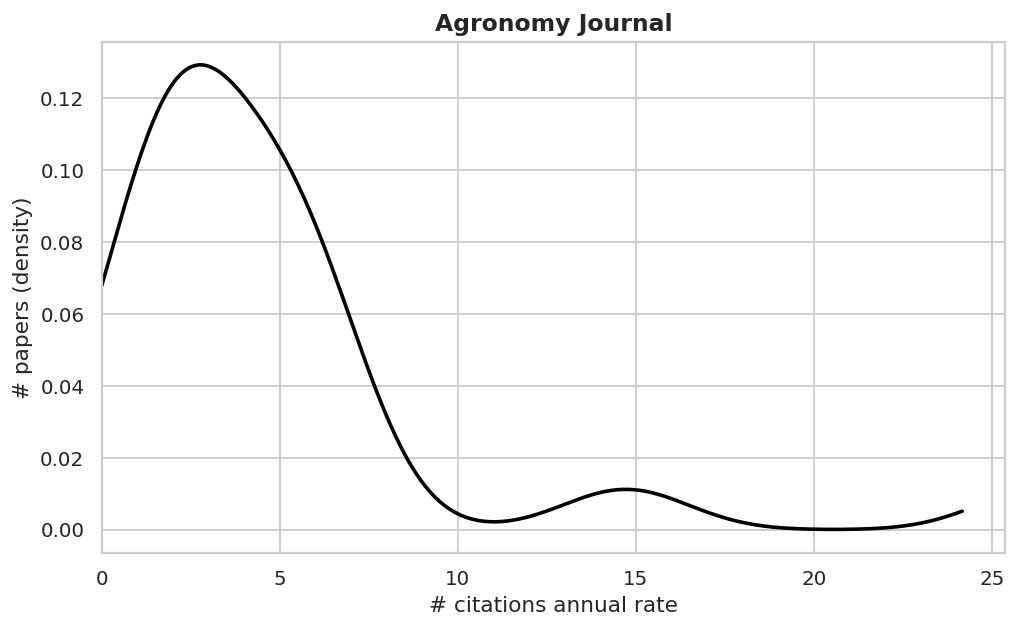

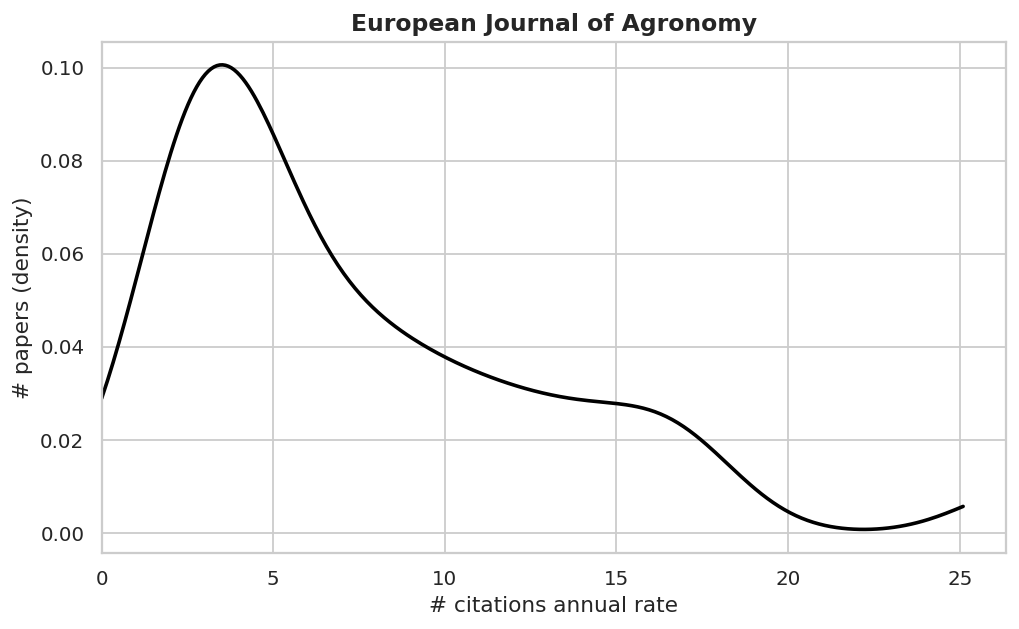

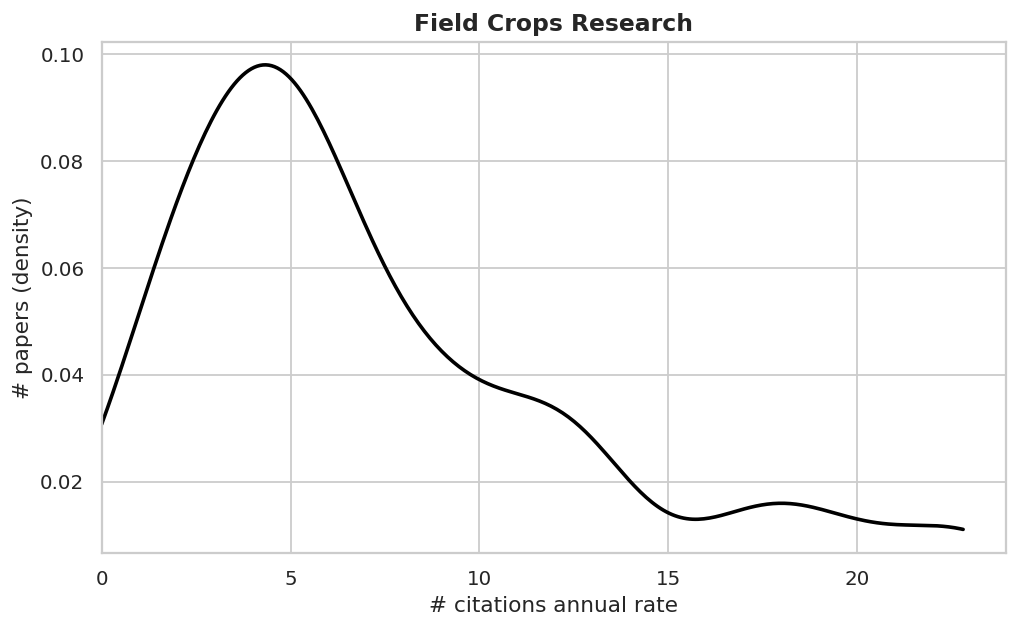

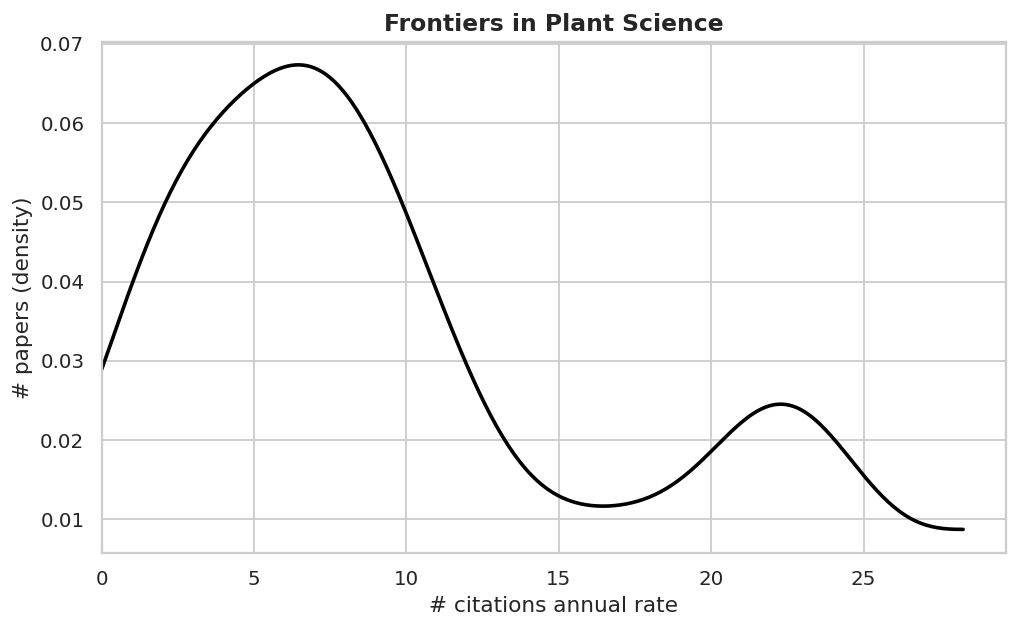

In [57]:
df=filtered_TargetA_df_corr.copy()
df["citations_per_year"] = (
    df["total_citations"] /
    (ACTUAL_Y - df["publication_year"])
)
for group_name, group_df in df.groupby('journal_display_name'):
    data = group_df['citations_per_year'].dropna()
    data = data[data > 0]

    if len(data) < 20:
            continue

    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(0, data.quantile(0.99), 300)
    y = kde(x)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y, color="black", linewidth=2)
    ax.set_xlabel("# citations annual rate", fontsize=12)
    ax.set_ylabel("# papers (density)", fontsize=12)
    ax.set_title(group_name, fontsize=13, fontweight="bold")
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()